In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib import ticker
import scipy.stats as stats_lib  
from scipy.stats import probplot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,VotingRegressor,StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
   mean_absolute_error, mean_squared_error, r2_score
)
import warnings
import os


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

In [3]:
df = pd.read_parquet("D:/vscode/NTI/amanfood/data/Food_Prices_in_Egypt.parquet")
df.head()

,Date,Year,Month,Season,Is_Ramadan,Annual_Sin,Annual_Cos,Governorate,Region,Market,Market_Type,Latitude,Longitude,Urbanization,Commodity,Category,Unit,Inflation_Index,Supply_Level,Demand_Level,Transport_Cost,Price_EGP,Split
0,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 1,Retail,31.22,29.93,0.96,Beans,Legumes,KG,103.57,76.10,76.10,5.26,52.06,Train
1,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 1,Retail,31.22,29.93,0.96,Eggplant,Vegetables,KG,103.57,84.26,73.98,5.10,24.81,Train
2,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 2,Retail,31.16,29.99,0.96,Grapes,Fruits,KG,103.57,68.52,69.00,5.00,54.51,Train
3,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 2,Retail,31.16,29.99,0.96,Vegetable Oil,Oils,L,103.57,76.06,77.08,5.20,90.33,Train
4,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 5,Retail,31.21,29.92,0.96,Eggs,Protein,DOZEN,103.57,72.37,72.83,6.28,80.66,Train


In [4]:
df.head()

,Date,Year,Month,Season,Is_Ramadan,Annual_Sin,Annual_Cos,Governorate,Region,Market,Market_Type,Latitude,Longitude,Urbanization,Commodity,Category,Unit,Inflation_Index,Supply_Level,Demand_Level,Transport_Cost,Price_EGP,Split
0,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 1,Retail,31.22,29.93,0.96,Beans,Legumes,KG,103.57,76.10,76.10,5.26,52.06,Train
1,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 1,Retail,31.22,29.93,0.96,Eggplant,Vegetables,KG,103.57,84.26,73.98,5.10,24.81,Train
2,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 2,Retail,31.16,29.99,0.96,Grapes,Fruits,KG,103.57,68.52,69.00,5.00,54.51,Train
3,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 2,Retail,31.16,29.99,0.96,Vegetable Oil,Oils,L,103.57,76.06,77.08,5.20,90.33,Train
4,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 5,Retail,31.21,29.92,0.96,Eggs,Protein,DOZEN,103.57,72.37,72.83,6.28,80.66,Train


In [5]:
df.shape

(488718, 23)

In [6]:
df.columns

Index(['Date', 'Year', 'Month', 'Season', 'Is_Ramadan', 'Annual_Sin',
       'Annual_Cos', 'Governorate', 'Region', 'Market', 'Market_Type',
       'Latitude', 'Longitude', 'Urbanization', 'Commodity', 'Category',
       'Unit', 'Inflation_Index', 'Supply_Level', 'Demand_Level',
       'Transport_Cost', 'Price_EGP', 'Split'],
      dtype='str')

In [7]:
df.info

<bound method DataFrame.info of               Date  Year  Month  Season  Is_Ramadan  Annual_Sin  Annual_Cos  \
0       2022-02-01  2022      2  Winter           0        0.51        0.86   
1       2022-02-01  2022      2  Winter           0        0.51        0.86   
2       2022-02-01  2022      2  Winter           0        0.51        0.86   
3       2022-02-01  2022      2  Winter           0        0.51        0.86   
4       2022-02-01  2022      2  Winter           0        0.51        0.86   
...            ...   ...    ...     ...         ...         ...         ...   
488713  2025-12-30  2025     12  Winter           0       -0.04        1.00   
488714  2025-12-30  2025     12  Winter           0       -0.04        1.00   
488715  2025-12-30  2025     12  Winter           0       -0.04        1.00   
488716  2025-12-30  2025     12  Winter           0       -0.04        1.00   
488717  2025-12-30  2025     12  Winter           0       -0.04        1.00   

       Governorate 

## Data Cleaning 🧹

In this section, we identify and handle missing values, duplicate records, incorrect data types, and invalid values to ensure that the dataset is clean and ready for analysis and modeling.

In [8]:
df.isnull().sum()

Date                  0
Year                  0
Month                 0
Season                0
Is_Ramadan            0
Annual_Sin            0
Annual_Cos            0
Governorate           0
Region                0
Market                0
Market_Type           0
Latitude              0
Longitude             0
Urbanization          0
Commodity             0
Category              0
Unit                  0
Inflation_Index       0
Supply_Level       4899
Demand_Level       4848
Transport_Cost     7236
Price_EGP             0
Split                 0
dtype: int64

In [9]:
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct (%)': (df.isnull().mean()) * 100
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)
missing_df

,Missing_Count,Missing_Pct (%)
Transport_Cost,7236,1.48
Supply_Level,4899,1.00
Demand_Level,4848,0.99


In [10]:
missing_columns = missing_df.index.tolist()

df[missing_columns].describe()

,Transport_Cost,Supply_Level,Demand_Level
count,"481,482.00","483,819.00","483,870.00"
mean,6.33,76.82,69.50
std,3.77,10.03,10.13
min,1.00,27.46,34.72
25%,3.85,69.63,62.41
50%,5.00,77.06,68.42
75%,9.32,84.21,75.10
max,18.37,100.00,100.00


In [11]:
df[
    [
        "Supply_Level",
        "Demand_Level",
        "Transport_Cost"
    ]
].corr()

,Supply_Level,Demand_Level,Transport_Cost
Supply_Level,1.00,-0.57,-0.17
Demand_Level,-0.57,1.00,-0.23
Transport_Cost,-0.17,-0.23,1.00


### Missing Values

In [12]:
# Fill Supply with median
df["Supply_Level"] = df["Supply_Level"].fillna(
    df["Supply_Level"].median()
)

In [13]:
#Fill Demand with median
df["Demand_Level"] = df["Demand_Level"].fillna(
    df["Demand_Level"].median()
)

In [14]:
#Fill Transport with median
df["Transport_Cost"] = df["Transport_Cost"].fillna(
    df["Transport_Cost"].median()
)

In [15]:
df[
    [
        "Supply_Level",
        "Demand_Level",
        "Transport_Cost"
    ]
].isnull().sum()

Supply_Level      0
Demand_Level      0
Transport_Cost    0
dtype: int64

### Duplicates

In [16]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Data Types

In [17]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

In [18]:
print(df["Date"].dtype)

datetime64[us]


In [19]:
# Check invalid prices
invalid_price = (df["Price_EGP"] <= 0).sum()
print("Invalid Price_EGP values:", invalid_price)

Invalid Price_EGP values: 0


In [20]:
# Check Supply range
invalid_supply = (
    (df["Supply_Level"] < 0) | (df["Supply_Level"] > 100)).sum()

In [21]:
print("Invalid Supply_Level values:", invalid_supply)

Invalid Supply_Level values: 0


In [22]:
# Check demand range
invalid_demand = (
    (df["Demand_Level"] < 0) | (df["Demand_Level"] > 100)).sum()

In [23]:
print("Invalid Demand_Level values:", invalid_demand)

Invalid Demand_Level values: 0


In [24]:
# Check Is_Ramadan values
print(df["Is_Ramadan"].value_counts())

Is_Ramadan
0    448020
1     40698
Name: count, dtype: int64


In [25]:
# Final cleaning check
print("Missing values:", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData shape:", df.shape)

Missing values: 0



Duplicate rows: 0

Data shape: (488718, 23)


# Exploratory Data Analysis (EDA) 📊

The goal of this section is to explore food price patterns and identify relationships between prices, commodities, locations, time, supply, and demand.

### Understanding the Categorical Variables

In [26]:
categorical_columns = df.select_dtypes(include="category").columns

categorical_columns

Index(['Season', 'Governorate', 'Region', 'Market', 'Market_Type', 'Commodity',
       'Category', 'Unit', 'Split'],
      dtype='str')

In [27]:
for col in categorical_columns:
    print(f"\n{col}:")
    print("Number of unique values:", df[col].nunique())
    print(df[col].unique())


Season:
Number of unique values: 4
['Winter', 'Spring', 'Summer', 'Autumn']
Categories (4, str): ['Autumn', 'Spring', 'Summer', 'Winter']

Governorate:
Number of unique values: 27
['Alexandria', 'Aswan', 'Asyut', 'Beheira', 'Beni Suef', ..., 'Red Sea', 'Sharqia', 'Sohag', 'South Sinai', 'Suez']
Length: 27
Categories (27, str): ['Alexandria', 'Aswan', 'Asyut', 'Beheira', ..., 'Sharqia', 'Sohag', 'South Sinai', 'Suez']

Region:
Number of unique values: 9
['Northern', 'Upper Egypt', 'Greater Cairo', 'Delta', 'Canal', 'Western', 'Desert', 'Sinai', 'Red Sea']
Categories (9, str): ['Canal', 'Delta', 'Desert', 'Greater Cairo', ..., 'Red Sea', 'Sinai', 'Upper Egypt', 'Western']

Market:
Number of unique values: 134
['Alexandria Retail Market 1', 'Alexandria Retail Market 2', 'Alexandria Retail Market 5', 'Alexandria Retail Market 6', 'Alexandria Retail Market 7', ..., 'Suez Retail Market 5', 'Suez Retail Market 6', 'Suez Retail Market 7', 'Suez Supermarket Market 4', 'Suez Wholesale Market 2'

In [28]:
numeric_columns = df.select_dtypes(include="number").columns

In [29]:
datetime_columns = df.select_dtypes(include="datetime").columns

### Commodity Distribution

We first explore the distribution of food commodities in the dataset to understand which products are represented and how frequently they occur.

In [30]:
commodity_counts = df["Commodity"].value_counts()
commodity_counts

Commodity
Chickpeas        24293
Eggplant         22864
Eggs             21435
Pepper           21435
Flour            18577
Lentils          18577
Mango            18577
Beef             17148
Chicken          17148
Garlic           17148
Orange           17148
Pasta            17148
Soybean Oil      17148
Carrot           15719
Potato           15719
Guava            14290
Tomato           14290
Vegetable Oil    14290
Yogurt           14290
Banana           12861
Wheat            12861
Corn             11432
Cucumber         11432
Grapes           11432
Onion            11432
Sunflower Oil    11432
Watermelon       11432
Apple            10003
Beans            10003
Cheese           10003
Fish             10003
Milk             10003
Rice              7145
Name: count, dtype: int64

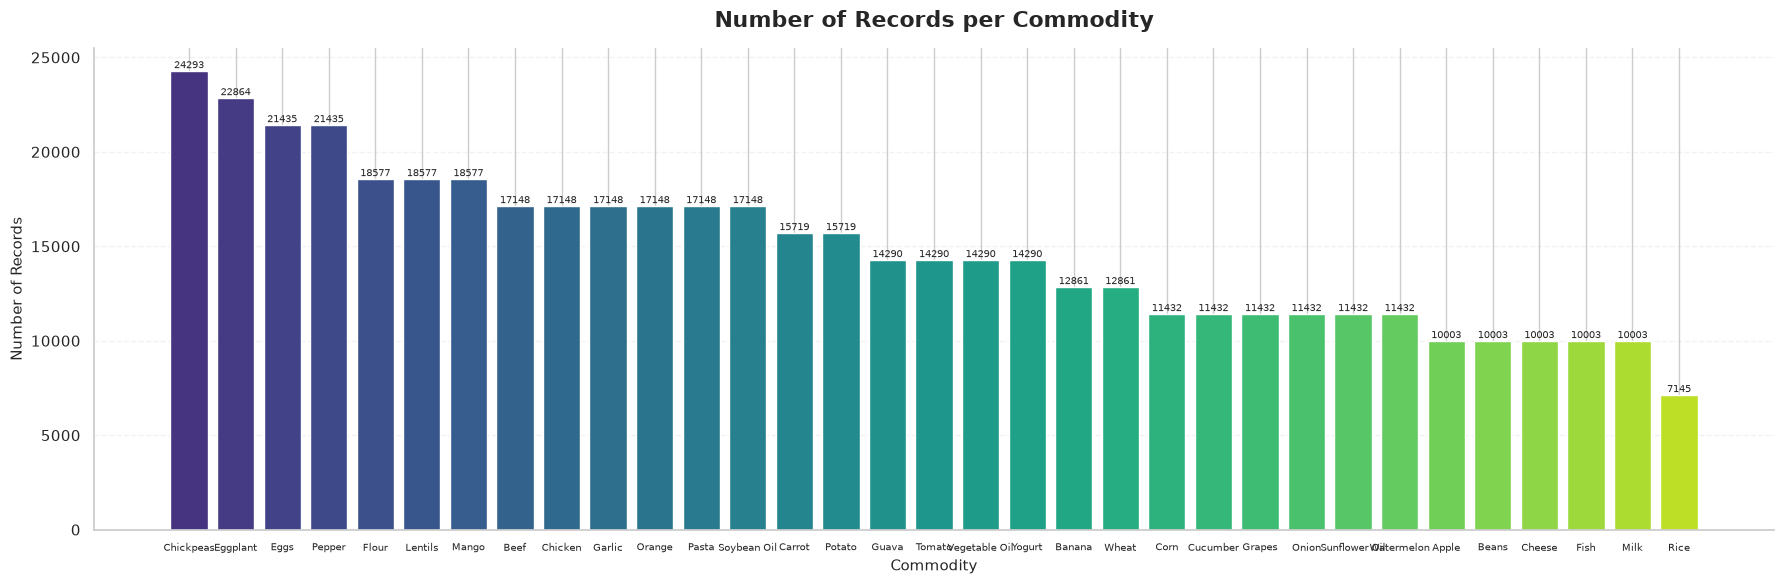

In [31]:
plt.figure(figsize=(18, 6))

bars = plt.bar(
    commodity_counts.index,
    commodity_counts.values,
    color=plt.cm.viridis(
        np.linspace(0.15, 0.9, len(commodity_counts))
    )
)

plt.title(
    "Number of Records per Commodity",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Commodity", fontsize=11)
plt.ylabel("Number of Records", fontsize=11)

# Make names smaller and slightly spaced
plt.xticks(
    rotation=0,
    fontsize=7
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 15,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=7
    )

plt.tight_layout()
plt.show()

In [32]:
# Top 5 commodities by number of records
print("Top 5 commodities:")
print(commodity_counts.head(5))

print("\nBottom 5 commodities:")
print(commodity_counts.tail(5))

Top 5 commodities:
Commodity
Chickpeas    24293
Eggplant     22864
Eggs         21435
Pepper       21435
Flour        18577
Name: count, dtype: int64

Bottom 5 commodities:
Commodity
Beans     10003
Cheese    10003
Fish      10003
Milk      10003
Rice       7145
Name: count, dtype: int64


### Governorate Distribution

In [33]:
governorate_counts = df["Governorate"].value_counts()
governorate_counts

Governorate
Cairo             40012
Ismailia          30009
Gharbia           28580
Asyut             27151
Qalyubia          25722
Red Sea           22864
Beheira           21435
Monufia           21435
Damietta          20006
Sharqia           20006
Port Said         18577
Alexandria        17148
Giza              15719
Kafr El Sheikh    15719
Minya             15719
Beni Suef         14290
Dakahlia          14290
Fayoum            14290
Sohag             14290
South Sinai       14290
Aswan             12861
Luxor             12861
Matrouh           12861
Qena              12861
Suez              12861
New Valley        10003
North Sinai        2858
Name: count, dtype: int64

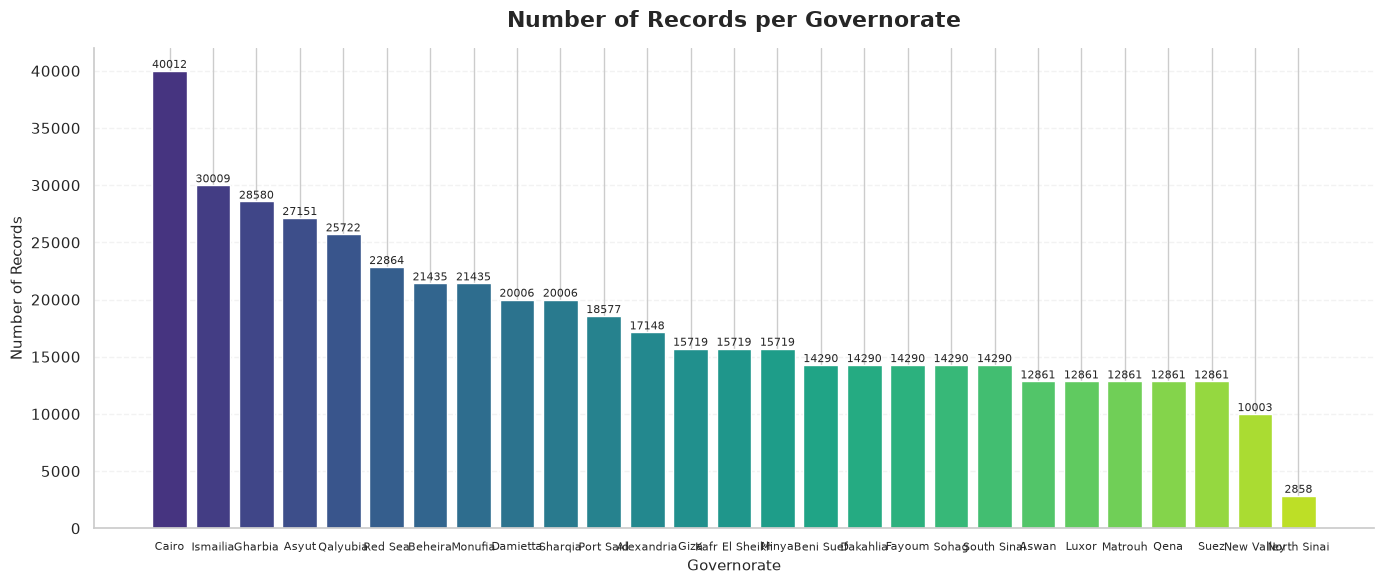

In [34]:
governorate_counts = df["Governorate"].value_counts()
plt.figure(figsize=(14, 6))

bars = plt.bar(
    governorate_counts.index,
    governorate_counts.values,
    color=plt.cm.viridis(
        np.linspace(0.15, 0.9, len(governorate_counts))
    )
)

plt.title(
    "Number of Records per Governorate",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Governorate", fontsize=11)
plt.ylabel("Number of Records", fontsize=11)

plt.xticks(
    rotation=0,
    fontsize=8
)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Light grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [35]:
print("Top 5 Governorates:")
print(governorate_counts.head(5))

print("\nBottom 5 Governorates:")
print(governorate_counts.tail(5))

Top 5 Governorates:
Governorate
Cairo       40012
Ismailia    30009
Gharbia     28580
Asyut       27151
Qalyubia    25722
Name: count, dtype: int64

Bottom 5 Governorates:
Governorate
Matrouh        12861
Qena           12861
Suez           12861
New Valley     10003
North Sinai     2858
Name: count, dtype: int64


### Price Analysis

#### Overall Price Distribution

In [36]:
price_stats = df["Price_EGP"].describe()
price_stats

count   488,718.00
mean         80.51
std         100.05
min           5.45
25%          31.05
50%          51.37
75%          92.69
max         891.93
Name: Price_EGP, dtype: float64

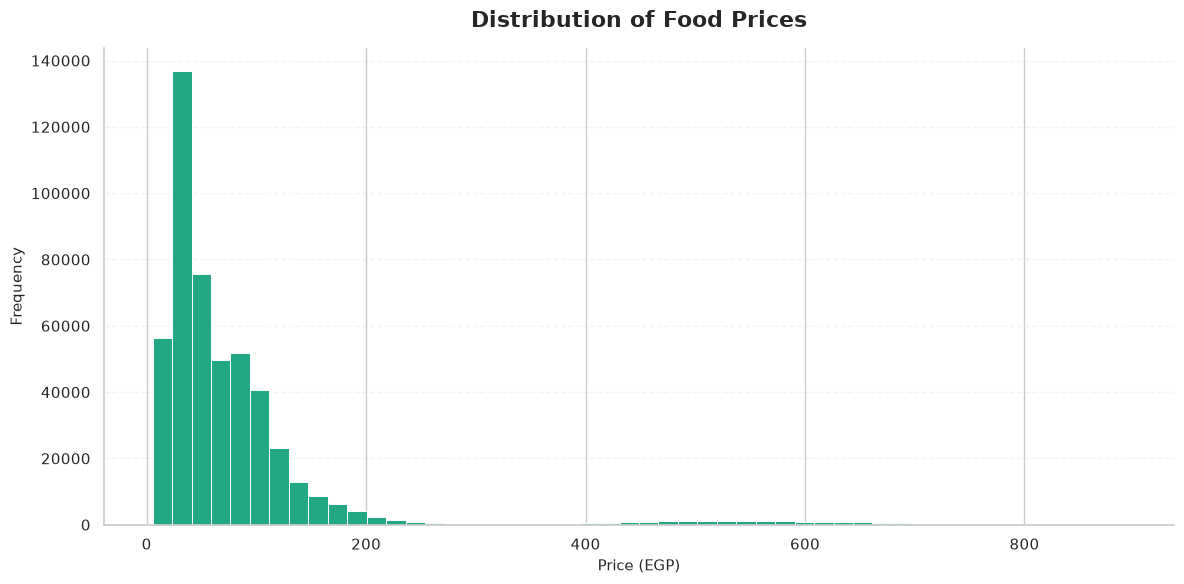

In [37]:
plt.figure(figsize=(12, 6))

plt.hist(
    df["Price_EGP"].dropna(),
    bins=50,
    color=plt.cm.viridis(0.6),
    edgecolor="white",
    linewidth=0.7
)

plt.title(
    "Distribution of Food Prices",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Price (EGP)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Light grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Insight

- The food price distribution is strongly right-skewed, with most observations concentrated at relatively lower prices.
- A long right tail can be observed, indicating the presence of some very high price observations.
- These high values may represent potential outliers, but they should not be removed automatically because they may reflect genuine market price differences.

#### Price Outlier Analysis

In [38]:
Q1 = df["Price_EGP"].quantile(0.25)
Q3 = df["Price_EGP"].quantile(0.75)

IQR = Q3 - Q1

lower_bound =max(0.5, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 31.054000854492188
Q3: 92.68699645996094
IQR: 61.63299560546875
Lower Bound: 0.5
Upper Bound: 185.13648986816406


In [39]:
outliers = df[(df["Price_EGP"] < lower_bound) |(df["Price_EGP"] > upper_bound)]
print("Number of outliers:", len(outliers))
print("Outlier percentage:", len(outliers) / len(df) * 100)

Number of outliers: 25956
Outlier percentage: 5.311038267467128


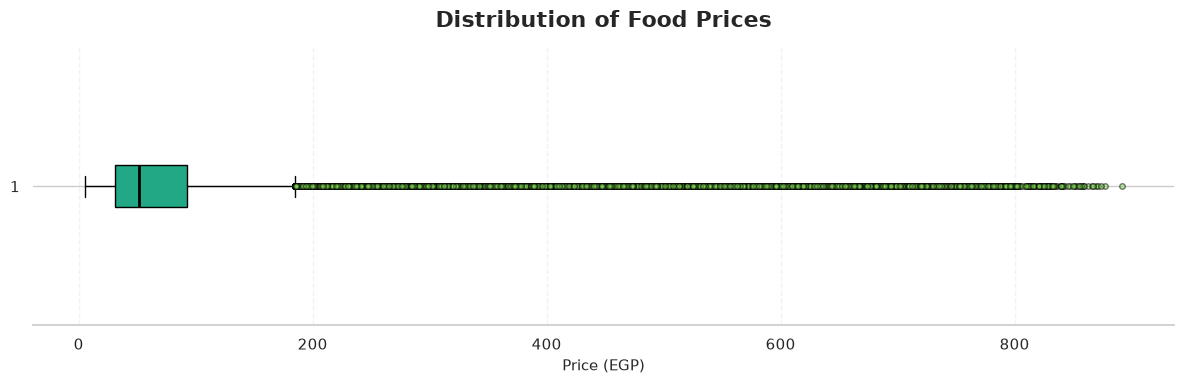

In [40]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    df["Price_EGP"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(
        facecolor=plt.cm.viridis(0.6),
        edgecolor="black"
    ),
    medianprops=dict(
        color="black",
        linewidth=2
    ),
    whiskerprops=dict(
        color="black"
    ),
    capprops=dict(
        color="black"
    ),
    flierprops=dict(
        marker="o",
        markerfacecolor=plt.cm.viridis(0.8),
        markeredgecolor="black",
        markersize=4,
        alpha=0.5
    )
)

plt.title(
    "Distribution of Food Prices",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Price (EGP)", fontsize=11)

# Clean appearance
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Insight

- The boxplot confirms the presence of a number of high-price observations beyond the upper whisker.
- Using the IQR method, 25,956 observations (5.31% of the dataset) were identified as potential outliers.
- These observations are retained because they may represent genuine differences in food prices rather than data errors.

#### Price Distribution by Commodity

In [41]:
commodity_price_stats = (df.groupby("Commodity", observed=True)["Price_EGP"].agg(["count", "mean", "median", "min", "max"]).sort_values("median", ascending=False))
commodity_price_stats

,count,mean,median,min,max
Commodity,,,,,
Beef,17148,546.16,540.10,267.31,891.93
Fish,10003,191.08,188.66,73.53,371.89
Cheese,10003,160.03,158.44,89.58,254.48
Chicken,17148,148.24,146.93,73.29,262.85
Sunflower Oil,11432,113.66,112.60,58.38,186.94
Vegetable Oil,14290,103.29,102.67,53.76,160.33
Soybean Oil,17148,103.89,102.53,57.21,173.05
Eggs,21435,98.70,97.45,48.20,186.45
Chickpeas,24293,90.93,90.11,46.30,153.46


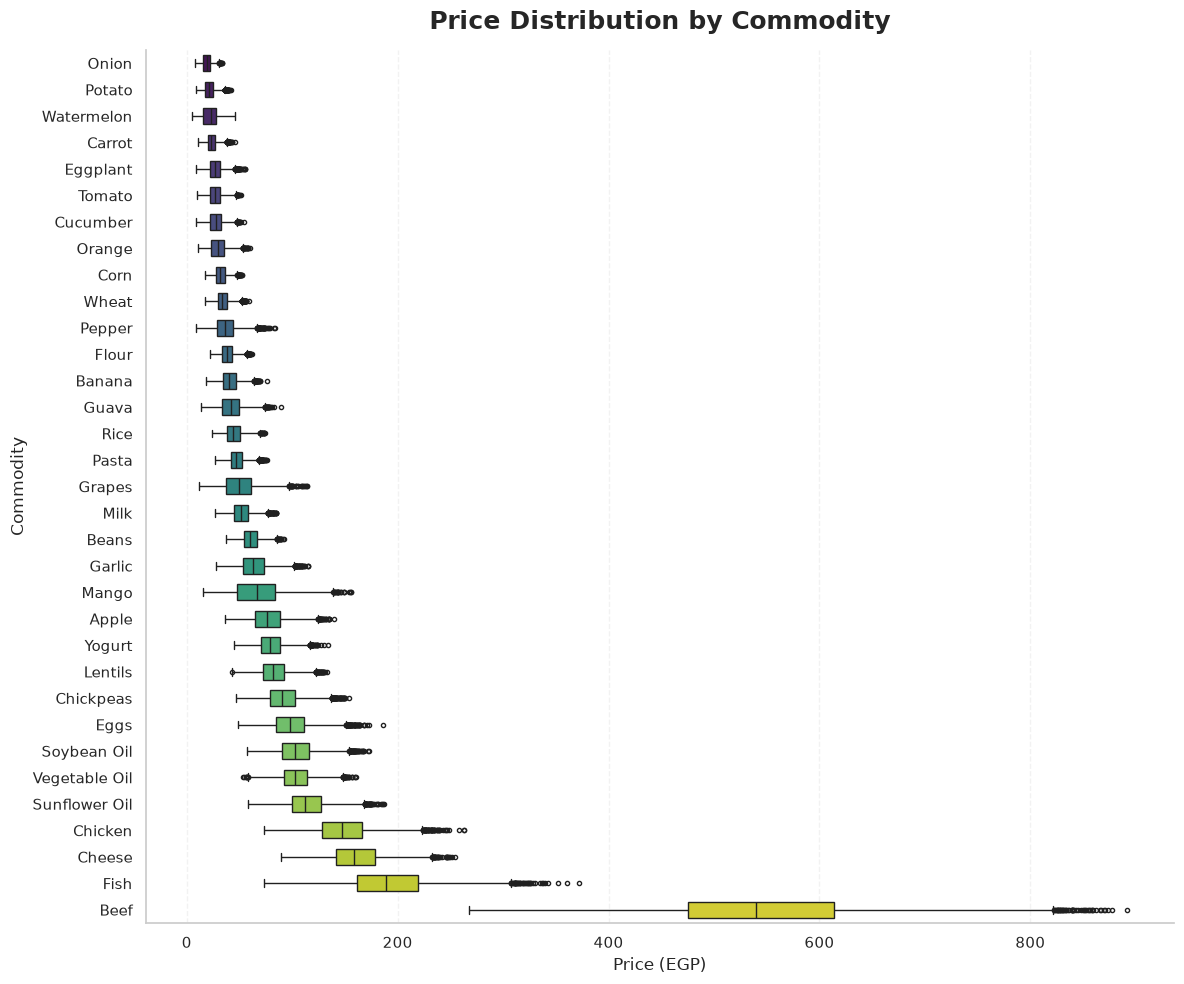

In [42]:
plt.figure(figsize=(12, 10))

commodity_median = (
    df.groupby("Commodity")["Price_EGP"]
    .median()
    .sort_values()
    .index
)

sns.boxplot(
    data=df,
    y="Commodity",
    x="Price_EGP",
    order=commodity_median,
    palette="viridis",
    width=0.6,
    fliersize=3
)

plt.title(
    "Price Distribution by Commodity",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Price (EGP)", fontsize=12)
plt.ylabel("Commodity", fontsize=12)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

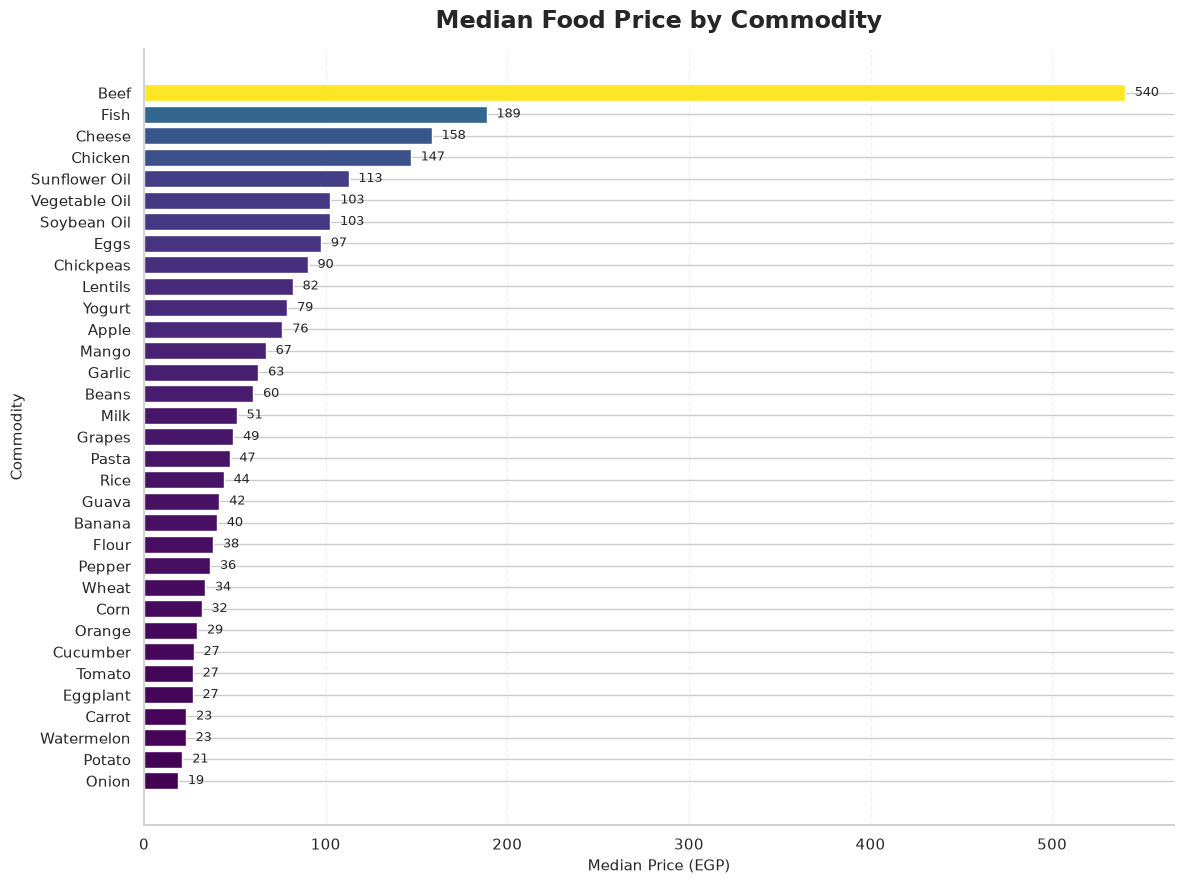

In [43]:
median_prices = (
    df.groupby("Commodity", observed=True)["Price_EGP"]
      .median()
      .sort_values(ascending=True)
)

plt.figure(figsize=(12, 9))

bars = plt.barh(
    median_prices.index,
    median_prices.values,
    color=plt.cm.viridis(
        (median_prices.values - median_prices.values.min()) /
        (median_prices.values.max() - median_prices.values.min())
    )
)

plt.title(
    "Median Food Price by Commodity",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Median Price (EGP)", fontsize=11)
plt.ylabel("Commodity", fontsize=11)

# Add values
for bar, value in zip(bars, median_prices.values):
    plt.text(
        value + median_prices.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center",
        fontsize=9
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Price Analysis by Governorate

#### Average and Median Price by Governorate

In [44]:
governorate_price_stats = (
    df.groupby("Governorate", observed=True)["Price_EGP"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("median", ascending=False)
)

governorate_price_stats

,count,mean,median,min,max
Governorate,,,,,
Sohag,14290,120.57,81.04,9.91,845.51
North Sinai,2858,105.33,80.91,14.39,254.48
Suez,12861,73.12,78.62,14.19,174.71
Giza,15719,120.44,77.28,17.26,795.18
Alexandria,17148,84.30,71.46,8.84,334.84
Damietta,20006,104.55,70.67,9.88,831.41
Qena,12861,69.05,65.89,7.85,173.05
Sharqia,20006,107.88,63.18,6.24,771.60
Cairo,40012,95.52,57.60,9.07,858.78


In [45]:
print("Top 5 Governorates by Median Price:")
print(governorate_price_stats["median"].head(5))

print("\nBottom 5 Governorates by Median Price:")
print(governorate_price_stats["median"].tail(5))

Top 5 Governorates by Median Price:
Governorate
Sohag         81.04
North Sinai   80.91
Suez          78.62
Giza          77.28
Alexandria    71.46
Name: median, dtype: float32

Bottom 5 Governorates by Median Price:
Governorate
Minya      41.65
Beheira    40.52
Ismailia   37.57
Matrouh    37.32
Qalyubia   34.85
Name: median, dtype: float32


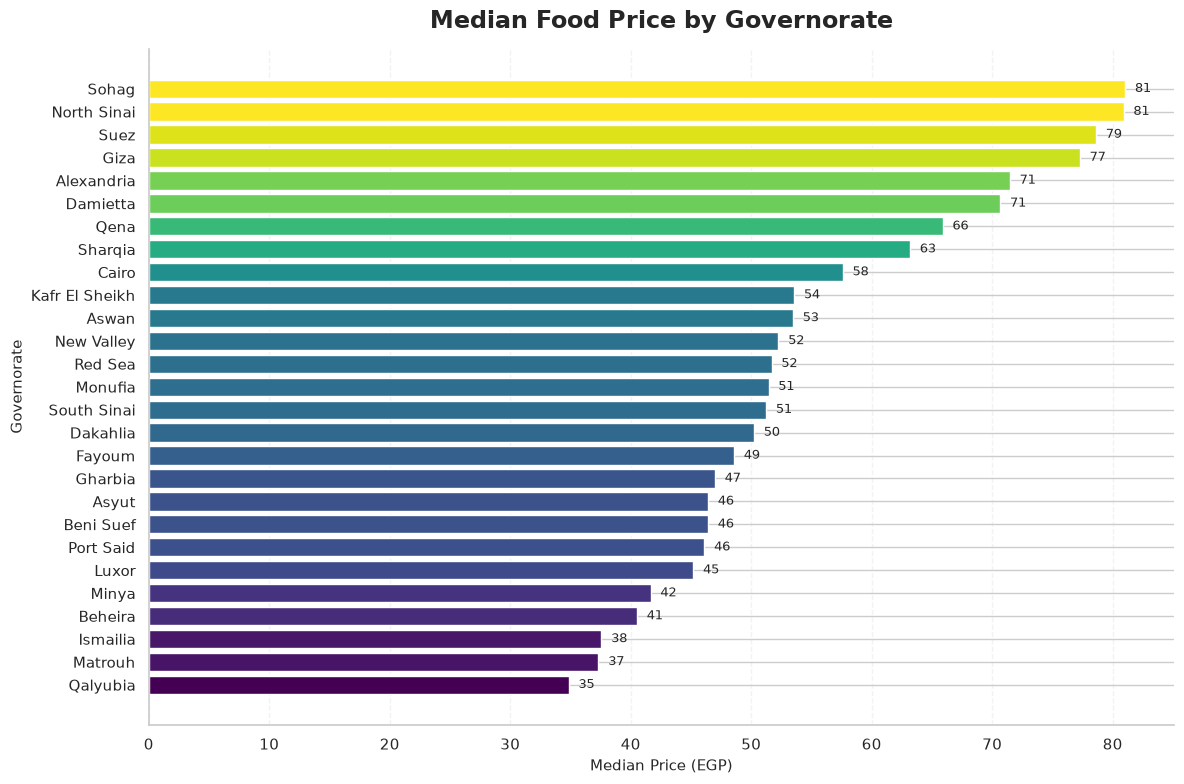

In [46]:
governorate_price_stats = (
    df.groupby("Governorate", observed=True)["Price_EGP"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("median", ascending=False)
)

median_governorate = governorate_price_stats["median"].sort_values()

plt.figure(figsize=(12, 8))

bars = plt.barh(
    median_governorate.index,
    median_governorate.values,
    color=plt.cm.viridis(
        (median_governorate.values - median_governorate.values.min()) /
        (median_governorate.values.max() - median_governorate.values.min())
    )
)

plt.title(
    "Median Food Price by Governorate",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Median Price (EGP)", fontsize=11)
plt.ylabel("Governorate", fontsize=11)

# Add values
for bar, value in zip(bars, median_governorate.values):
    plt.text(
        value + median_governorate.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center",
        fontsize=9
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

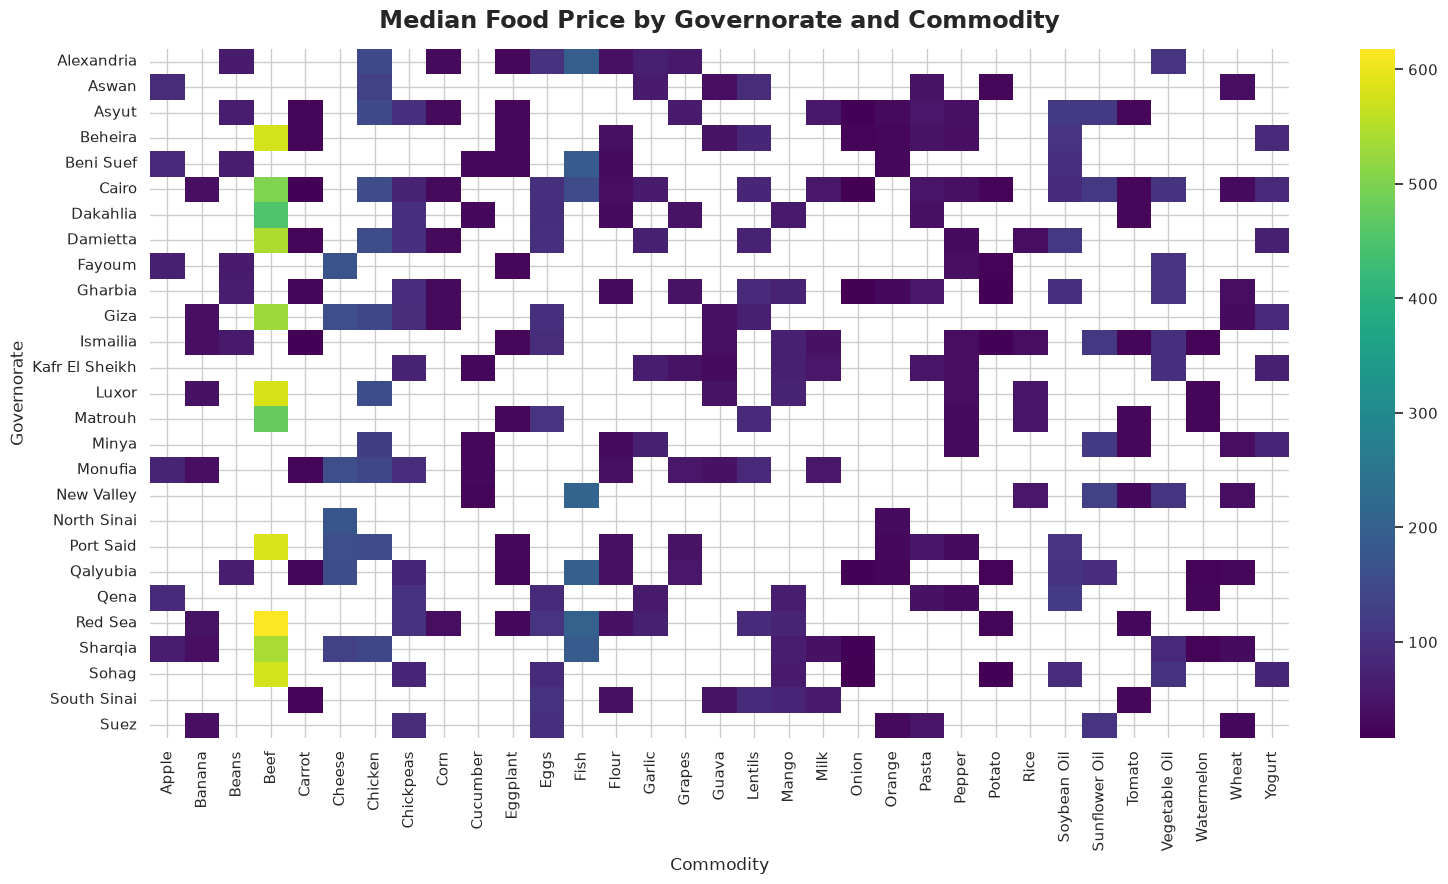

In [47]:
price_heatmap = (
    df.pivot_table(
        index="Governorate",
        columns="Commodity",
        values="Price_EGP",
        aggfunc="median",
        observed=True
    )
)

plt.figure(figsize=(16, 9))

sns.heatmap(
    price_heatmap,
    cmap="viridis",
    annot=False
)

plt.title(
    "Median Food Price by Governorate and Commodity",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Commodity")
plt.ylabel("Governorate")

plt.tight_layout()
plt.show()

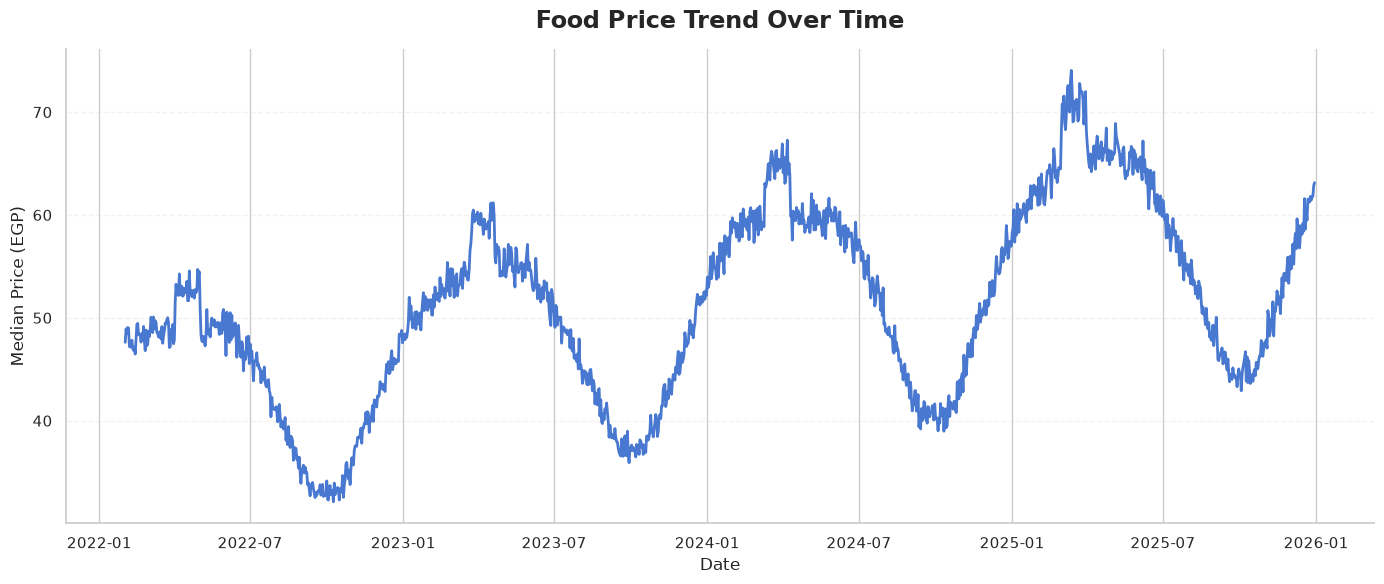

In [48]:
monthly_price = (
    df.groupby("Date", observed=True)["Price_EGP"]
      .median()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_price.index,
    monthly_price.values,
    linewidth=2
)

plt.title(
    "Food Price Trend Over Time",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Date")
plt.ylabel("Median Price (EGP)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

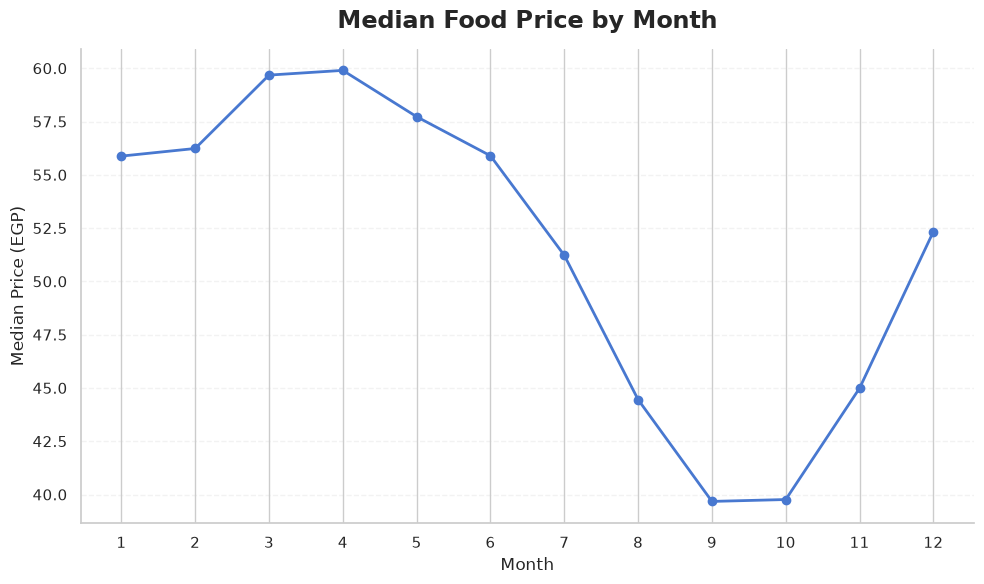

In [49]:
monthly_seasonality = (
    df.groupby("Month", observed=True)["Price_EGP"]
      .median()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Median Food Price by Month",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month")
plt.ylabel("Median Price (EGP)")

plt.xticks(range(1, 13))

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

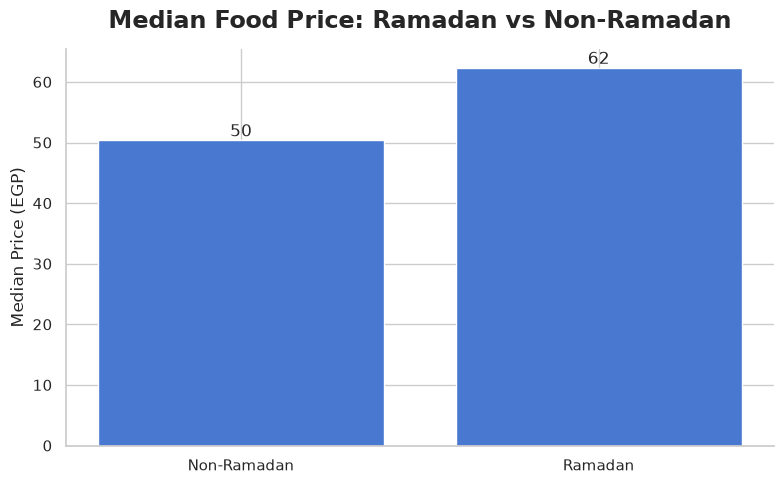

In [50]:
ramadan_prices = (
    df.groupby("Is_Ramadan", observed=True)["Price_EGP"]
      .median()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Non-Ramadan", "Ramadan"],
    ramadan_prices.values
)

plt.title(
    "Median Food Price: Ramadan vs Non-Ramadan",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.ylabel("Median Price (EGP)")

for bar, value in zip(bars, ramadan_prices.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.0f}",
        ha="center",
        va="bottom"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

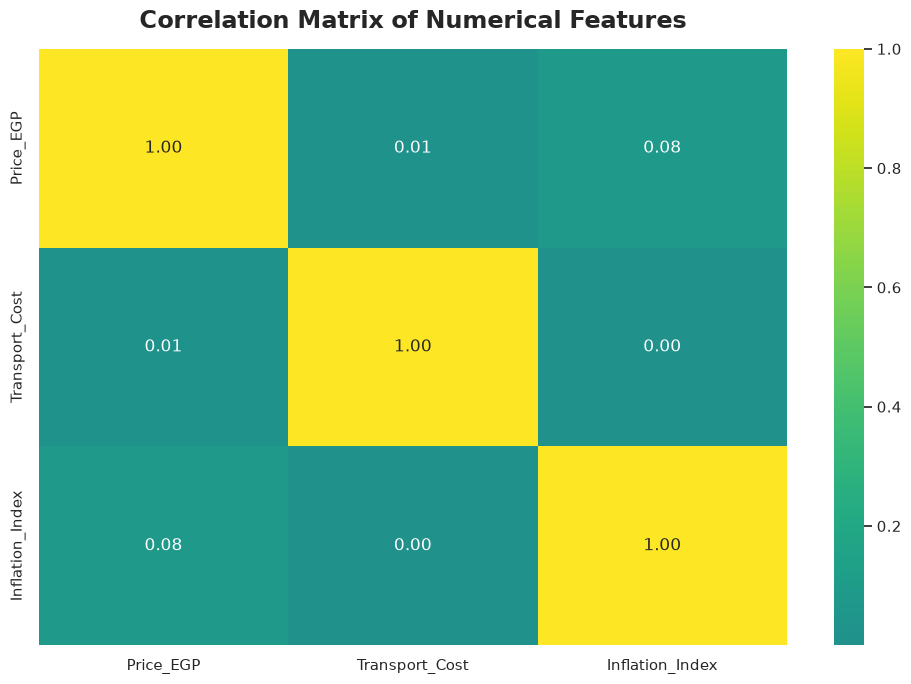

In [51]:
numeric_cols = [
    "Price_EGP",
    "Transport_Cost",
    "Inflation_Index",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    center=0
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

In [52]:
geo_summary = df.groupby(
    ['Governorate', 'Market', 'Market_Type', 'Latitude', 'Longitude'],
    as_index=False
).agg(
    Avg_Price_EGP=('Price_EGP', 'mean'),
    Total_Records=('Price_EGP', 'count'),
    Avg_Transport_Cost=('Transport_Cost', 'mean')
)

fig_map = px.scatter_mapbox(
    geo_summary,
    lat='Latitude',
    lon='Longitude',
    size='Total_Records',
    size_max=16,
    color='Avg_Price_EGP',
    color_continuous_scale=px.colors.sequential.Turbo,
    hover_name='Market',
    hover_data={
        'Governorate': True,
        'Market_Type': True,
        'Avg_Price_EGP': ':.2f',
        'Avg_Transport_Cost': ':.2f',
        'Total_Records': True,
        'Latitude': False,
        'Longitude': False
    },
    zoom=5.8,
    center={"lat": 26.9, "lon": 30.8},
    mapbox_style="open-street-map",
    title="<b>Egypt Food Market Network: Price Levels & Geographic Density</b>"
)

fig_map.update_layout(
    height=800,
    width=1200,
    margin=dict(r=30, t=70, l=30, b=30),
    coloraxis_colorbar=dict(
        title=dict(
            text="Avg Price (EGP)",
            font=dict(size=14, color="#0f172a", family="Arial, sans-serif")
        ),
        tickfont=dict(size=12, color="#1e293b"),
        thickness=22,
        len=0.75
    ),
    title=dict(
        font=dict(size=20, color="#0f172a", family="Arial, sans-serif"),
        x=0.03,
        y=0.97
    )
)

fig_map.update_traces(
    marker=dict(
        opacity=0.88
    )
)

fig_map.show()

In [53]:
sunburst_df = df.groupby(['Category', 'Commodity'], as_index=False).agg(
    Avg_Price=('Price_EGP', 'mean'),
    Record_Count=('Price_EGP', 'count')
)

fig_sunburst = px.sunburst(
    sunburst_df,
    path=['Category', 'Commodity'],
    values='Record_Count',
    color='Avg_Price',
    color_continuous_scale=px.colors.diverging.Spectral_r,
    title="<b>Hierarchical Food Basket Composition & Price Hierarchy</b>",
    template="plotly_white"
)

fig_sunburst.update_layout(
    margin=dict(t=50, l=0, r=0, b=0),
    coloraxis_colorbar=dict(title="Avg Price (EGP)")
)

fig_sunburst.show()

In [54]:
key_items = ['Rice', 'Beef', 'Chicken', 'Vegetable Oil', 'Tomato', 'Flour', 'Beans', 'Sugar']
filtered_trend = df[df['Commodity'].isin(key_items)].copy()
filtered_trend['Date'] = pd.to_datetime(filtered_trend['Date'])

monthly_trend = filtered_trend.groupby(
    ['Date', 'Commodity'],
    as_index=False
)['Price_EGP'].mean()

fig_trend = px.line(
    monthly_trend,
    x='Date',
    y='Price_EGP',
    color='Commodity',
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="<b>Macro Price Dynamics of Key Egyptian Commodities Over Time</b>",
    labels={'Price_EGP': 'Average Price (EGP)', 'Date': 'Timeline'},
    template="plotly_white"
)

fig_trend.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=6, label="6M", step="month", stepmode="backward"),
            dict(count=1, label="1Y", step="year", stepmode="backward"),
            dict(count=3, label="3Y", step="year", stepmode="backward"),
            dict(step="all", label="All")
        ])
    )
)

fig_trend.update_layout(
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig_trend.show()

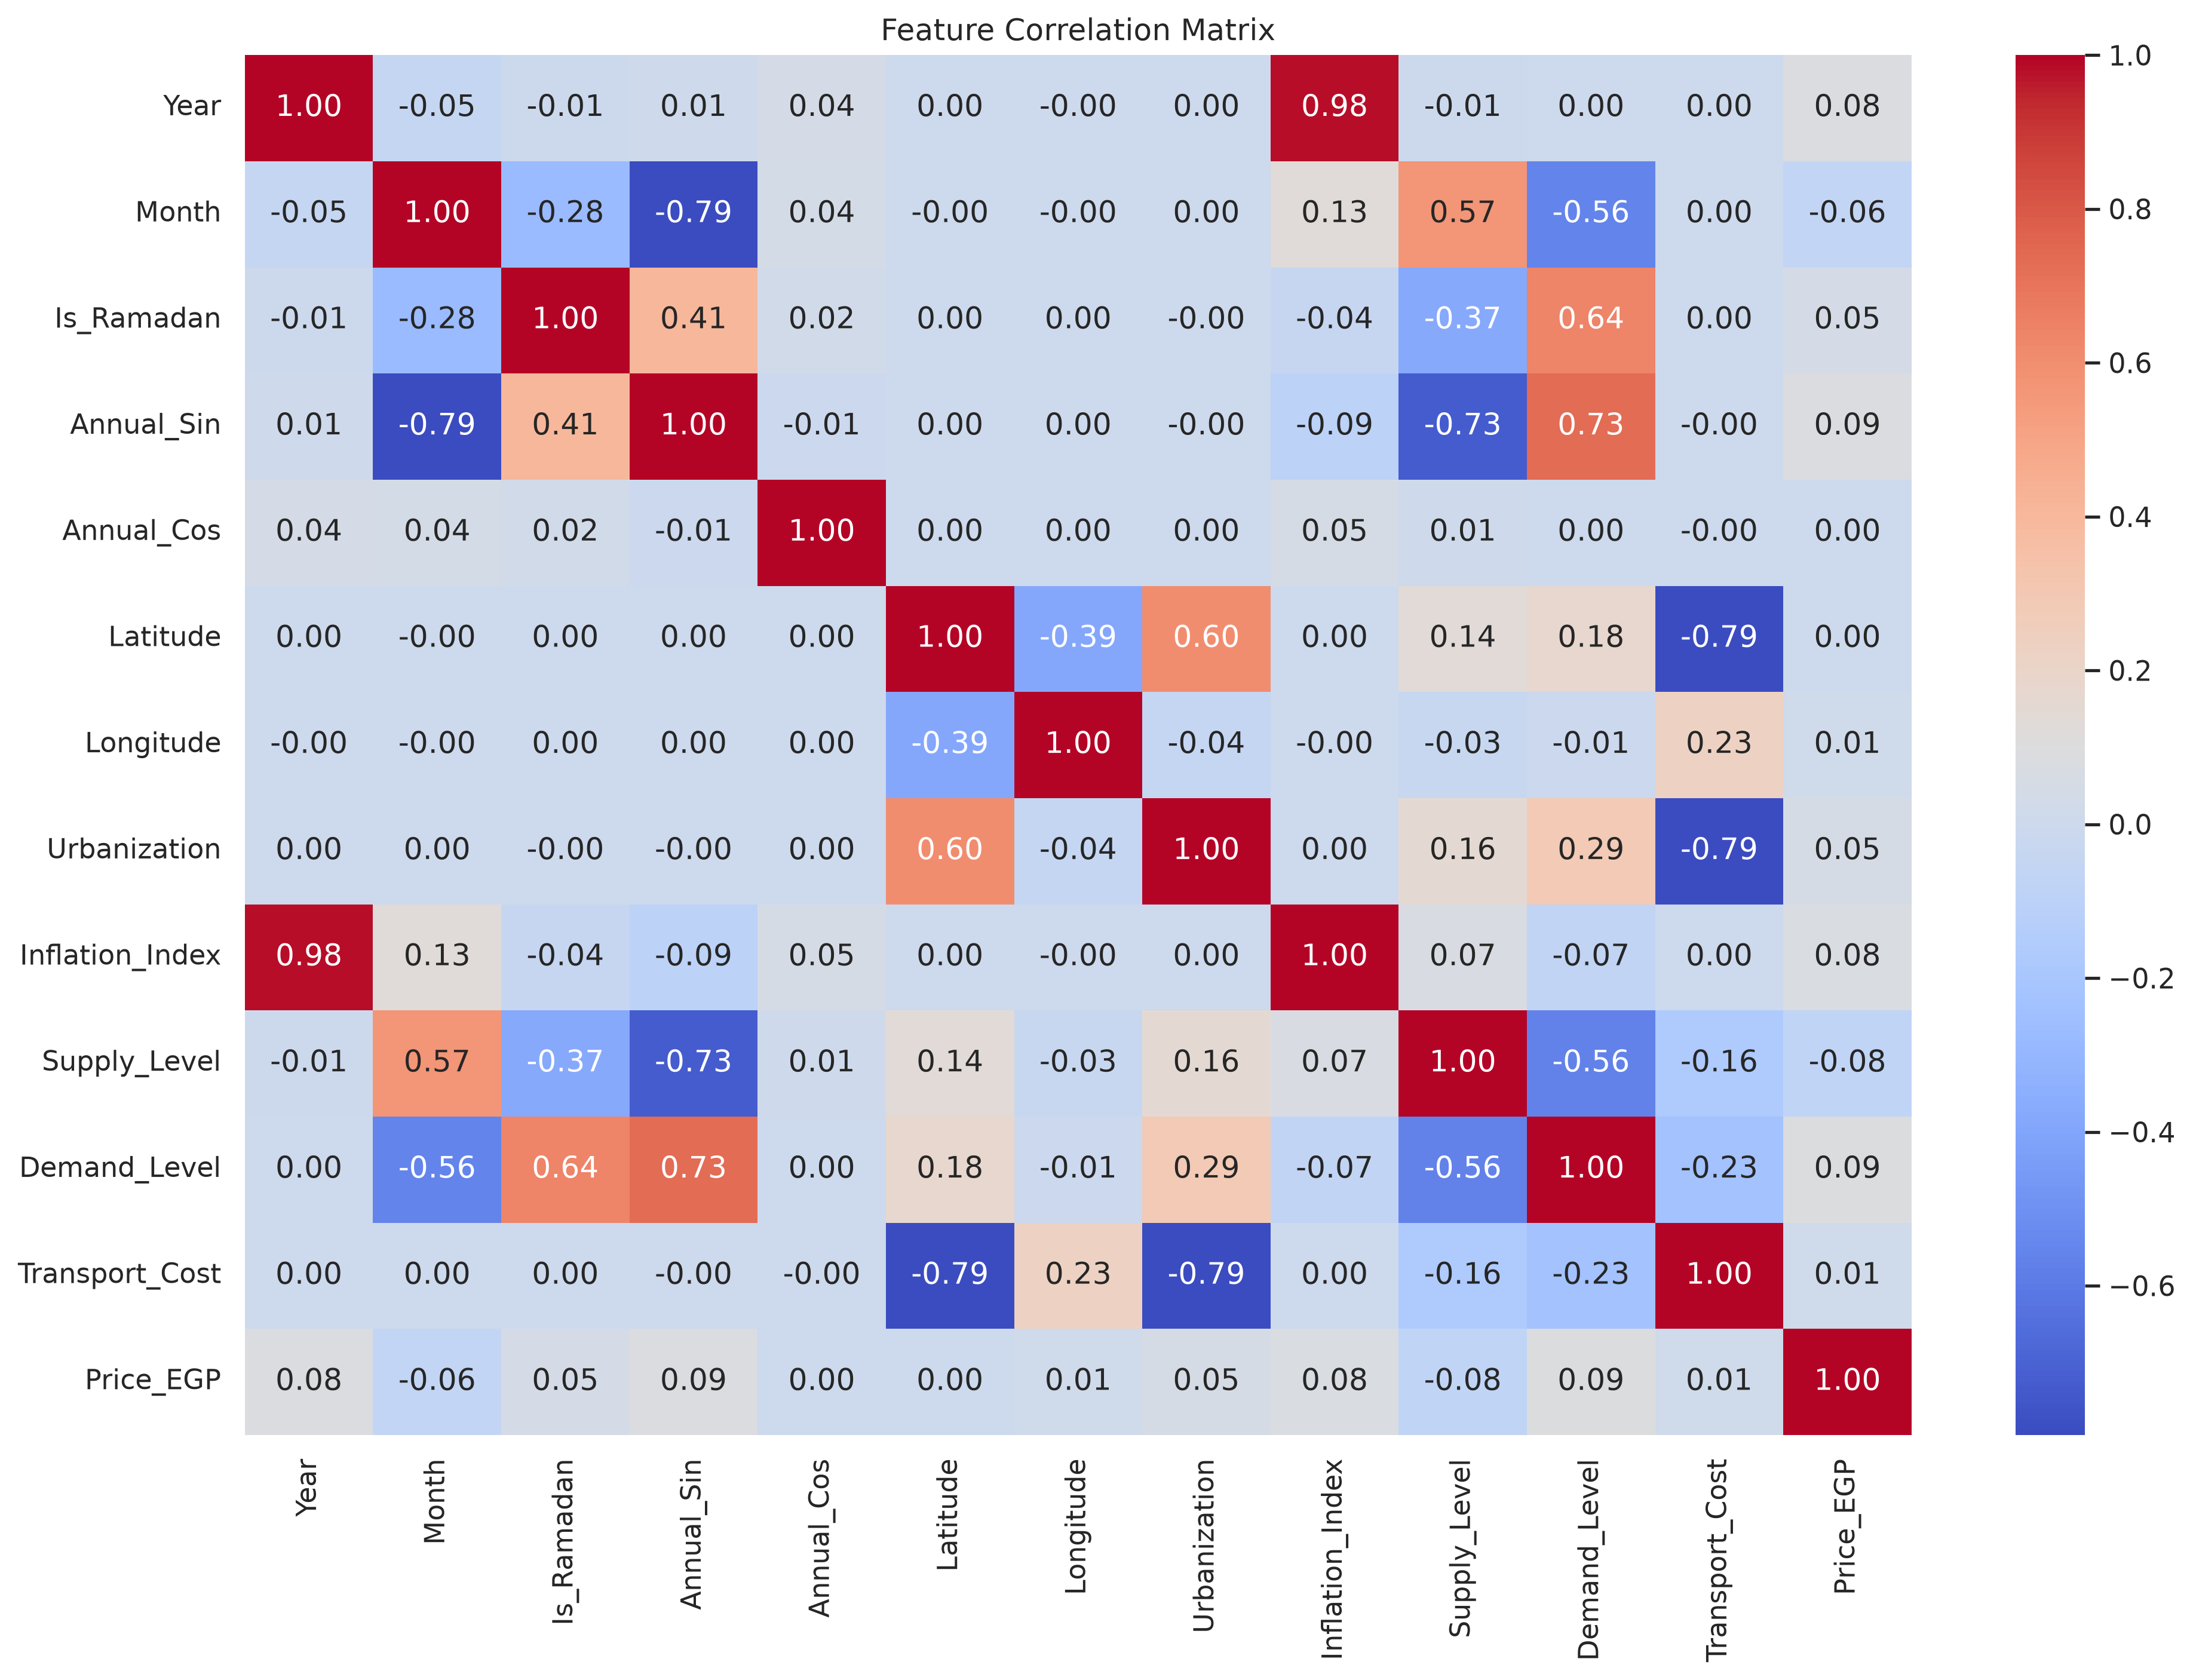

In [55]:
plt.figure(figsize=(15, 10),dpi=300)
sns.heatmap(df.corr(numeric_only=True), annot=True,fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# Dropping Unnecessary Columns 🗑️

In this section, we drop columns that are either data leakage sources (features derived from future or target-related information), identifiers not useful for modeling, or redundant with other existing features.

In [56]:
df.head()

,Date,Year,Month,Season,Is_Ramadan,Annual_Sin,Annual_Cos,Governorate,Region,Market,Market_Type,Latitude,Longitude,Urbanization,Commodity,Category,Unit,Inflation_Index,Supply_Level,Demand_Level,Transport_Cost,Price_EGP,Split
0,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 1,Retail,31.22,29.93,0.96,Beans,Legumes,KG,103.57,76.10,76.10,5.26,52.06,Train
1,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 1,Retail,31.22,29.93,0.96,Eggplant,Vegetables,KG,103.57,84.26,73.98,5.10,24.81,Train
2,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 2,Retail,31.16,29.99,0.96,Grapes,Fruits,KG,103.57,68.52,69.00,5.00,54.51,Train
3,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 2,Retail,31.16,29.99,0.96,Vegetable Oil,Oils,L,103.57,76.06,77.08,5.20,90.33,Train
4,2022-02-01,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 5,Retail,31.21,29.92,0.96,Eggs,Protein,DOZEN,103.57,72.37,72.83,6.28,80.66,Train


# Data Cleaning: Duplicate Check 🔍

In this section, we check whether the dataset contains any duplicate rows, to ensure the data quality before proceeding with feature engineering and modeling.

In [57]:
print("duplicated columns", df.duplicated().sum())

duplicated columns 0


# Train/ Test Split 🧩

In this section, we split the dataset into training and testing sets based on the predefined Split column, to properly evaluate model performance.

In [58]:
FEATURES = [
    'Governorate', 'Region', 'Market_Type', 'Commodity', 'Category', 'Unit', 'Season',
    'Year', 'Month', 'Is_Ramadan', 'Annual_Sin', 'Annual_Cos',
    'Inflation_Index', 'Supply_Level', 'Demand_Level', 'Transport_Cost', 'Urbanization'
]

TARGET = 'Price_EGP'

train_mask = df['Split'].isin(['Train', 'Validation'])
test_mask = df['Split'] == 'Test'

X_train = df.loc[train_mask, FEATURES]
y_train = df.loc[train_mask, TARGET]

X_test = df.loc[test_mask, FEATURES]
y_test = df.loc[test_mask, TARGET]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

X_train shape: (364230, 17)
X_test shape : (124488, 17)


# Feature Scaling 📏

In this section, we standardize the numerical features using StandardScaler, so that all features are on the same scale and the model can learn effectively.

In [59]:
X_train=pd.get_dummies(X_train,drop_first=True,dtype=int)
X_test=pd.get_dummies(X_test,drop_first=True,dtype=int)

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

feature_names = X_train.columns.tolist()

scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
model_comparison_df = pd.DataFrame()

def evaluate_and_plot_model(
    model,
    model_name,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    feature_names=feature_names
):
    global model_comparison_df

    y_train_pred_raw = model.predict(X_train)
    y_test_pred_raw = model.predict(X_test)

    y_train_real = np.expm1(y_train)
    y_train_pred_real = np.expm1(y_train_pred_raw)
    y_test_real = np.expm1(y_test)
    y_test_pred_real = np.expm1(y_test_pred_raw)

    y_train_arr = np.array(y_train_real).ravel()
    y_train_pred_arr = np.array(y_train_pred_real).ravel()
    y_test_arr = np.array(y_test_real).ravel()
    y_test_pred_arr = np.array(y_test_pred_real).ravel()

    train_residuals = y_train_arr - y_train_pred_arr
    test_residuals = y_test_arr - y_test_pred_arr

    r2_train = r2_score(y_train_arr, y_train_pred_arr) * 100
    r2_test = r2_score(y_test_arr, y_test_pred_arr) * 100
    r2_gap = r2_train - r2_test

    mae_train = mean_absolute_error(y_train_arr, y_train_pred_arr)
    mae_test = mean_absolute_error(y_test_arr, y_test_pred_arr)

    rmse_train = np.sqrt(mean_squared_error(y_train_arr, y_train_pred_arr))
    rmse_test = np.sqrt(mean_squared_error(y_test_arr, y_test_pred_arr))

    metrics_dict = {
        'Model Name': model_name,
        'R2 Train (%)': r2_train,
        'R2 Test (%)': r2_test,
        'R2 Gap (%)': r2_gap,
        'MAE Train': mae_train,
        'MAE Test': mae_test,
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
    }

    current_df = pd.DataFrame([metrics_dict])
    model_comparison_df = pd.concat(
        [model_comparison_df, current_df], ignore_index=True
    ).drop_duplicates(subset=['Model Name'], keep='last')

    print(f"\n{'='*25} {model_name} Generalization Diagnostics {'='*25}")
    print(f"Train R²: {r2_train:.2f}% | Test R²: {r2_test:.2f}% | Overfitting Gap: {r2_gap:+.2f}%")
    print(f"Train MAE: {mae_train:,.2f} | Test MAE: {mae_test:,.2f}")
    print(f"Train RMSE: {rmse_train:,.2f} | Test RMSE: {rmse_test:,.2f}")
    print('='*75)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#FFFFFF')
    fig.suptitle(f'Performance Diagnostics: {model_name} (Train vs Test Comparison)', 
                 fontsize=15, fontweight='bold', color='#0F172A', y=0.98)

    axes[0].scatter(
        y_train_arr, y_train_pred_arr,
        color='#94A3B8', alpha=0.25, s=20, edgecolors='none', label=f'Train Data (R²: {r2_train:.1f}%)'
    )
    sc = axes[0].scatter(
        y_test_arr, y_test_pred_arr,
        c=np.abs(test_residuals), cmap='plasma', alpha=0.75, s=35, edgecolors='none', label=f'Test Data (R²: {r2_test:.1f}%)'
    )
    
    min_val = min(y_test_arr.min(), y_train_arr.min())
    max_val = max(y_test_arr.max(), y_train_arr.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], color='#EF4444', linestyle='--', linewidth=2.0, label='Ideal 45° Line')

    axes[0].set_title('Actual vs Predicted Parity Plot', fontsize=12, fontweight='bold', color='#1E293B', pad=10)
    axes[0].set_xlabel('Actual Real Values', fontsize=10, fontweight='bold')
    axes[0].set_ylabel('Predicted Real Values', fontsize=10, fontweight='bold')
    axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[0].grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')
    axes[0].legend(frameon=True, facecolor='white', edgecolor='#E2E8F0', loc='upper left')
    
    cb = plt.colorbar(sc, ax=axes[0], pad=0.02)
    cb.set_label('Absolute Test Error', fontsize=9)

    sns.kdeplot(
        train_residuals, ax=axes[1], color='#64748B', linestyle='--', linewidth=2, label='Train Residuals'
    )
    sns.histplot(
        test_residuals, ax=axes[1], bins=40, kde=True, color='#2563EB', stat="density", alpha=0.5, edgecolor='white', label='Test Residuals'
    )
    axes[1].axvline(0, color='#EF4444', linestyle=':', linewidth=1.5, label='Zero Error Target')

    axes[1].set_title('Residual Density Spread: Bias & Variance Check', fontsize=12, fontweight='bold', color='#1E293B', pad=10)
    axes[1].set_xlabel('Residual Error (Actual - Predicted)', fontsize=10, fontweight='bold')
    axes[1].set_ylabel('Probability Density', fontsize=10, fontweight='bold')
    axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    axes[1].grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')
    axes[1].legend(frameon=True, facecolor='white', edgecolor='#E2E8F0', loc='upper right')

    plt.tight_layout()
    plt.show()

    plot_interactive_specifics(
        model, model_name, X_train, y_train, feature_names
    )

    styled_df = current_df.style.format({
        'R2 Train (%)': '{:.2f}%',
        'R2 Test (%)': '{:.2f}%',
        'R2 Gap (%)': '{:+.2f}%',
        'MAE Train': '{:,.2f}',
        'MAE Test': '{:,.2f}',
        'RMSE Train': '{:,.2f}',
        'RMSE Test': '{:,.2f}',
    }).background_gradient(cmap='Blues', subset=['R2 Test (%)'])\
      .background_gradient(cmap='Reds', subset=['R2 Gap (%)'])

    return styled_df


def plot_interactive_specifics(
    model, model_name, X_train=None, y_train=None, feature_names=None
):
    if X_train is not None and hasattr(X_train, 'shape'):
        expected_len = X_train.shape[1]
        if feature_names is None or len(feature_names) != expected_len:
            if hasattr(X_train, 'columns'):
                feature_names = list(X_train.columns)
            else:
                feature_names = [f'Feature {i}' for i in range(expected_len)]

    if model.__class__.__name__ == 'MLPRegressor':
        fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), facecolor='#FFFFFF')
        fig.suptitle(f'Neural Architecture Diagnostics: {model_name}', fontsize=14, fontweight='bold', color='#0F172A', y=1.02)

        if hasattr(model, 'loss_curve_'):
            axes[0].plot(model.loss_curve_, color='#2563EB', linewidth=2.2, label='Training Loss')
            axes[0].set_title('Optimization Loss Convergence Trajectory', fontsize=12, fontweight='bold', pad=10)
            axes[0].set_xlabel('Epoch / Iterations', fontsize=10, fontweight='bold')
            axes[0].set_ylabel('Loss Metric (MSE / Log-Loss)', fontsize=10, fontweight='bold')
            axes[0].grid(True, linestyle='--', alpha=0.5, color='#CBD5E1')
            
            final_loss = model.loss_curve_[-1]
            axes[0].scatter(len(model.loss_curve_) - 1, final_loss, color='#EF4444', s=60, zorder=5)
            axes[0].annotate(f'Final Loss: {final_loss:.4f}', 
                             xy=(len(model.loss_curve_) - 1, final_loss),
                             xytext=(-80, 15), textcoords='offset points',
                             bbox=dict(boxstyle="round,pad=0.3", fc="#FEF2F2", ec="#EF4444", lw=1),
                             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color="#EF4444"))
            axes[0].legend(frameon=True, facecolor='white', edgecolor='#E2E8F0')

        if hasattr(model, 'coefs_'):
            layer_weights = [np.abs(w).ravel() for w in model.coefs_]
            layer_labels = [f'Layer {i}→{i+1}\n({w.shape[0]}x{w.shape[1]})' for i, w in enumerate(model.coefs_)]
            
            vp = axes[1].violinplot(layer_weights, showmeans=True, showmedians=False)
            for body in vp['bodies']:
                body.set_facecolor('#8B5CF6')
                body.set_edgecolor('#5B21B6')
                body.set_alpha(0.6)
            vp['cmeans'].set_color('#1E293B')
            
            axes[1].set_xticks(range(1, len(layer_labels) + 1))
            axes[1].set_xticklabels(layer_labels, fontsize=9)
            axes[1].set_title('Synaptic Weight Magnitude Distribution (|W|)', fontsize=12, fontweight='bold', pad=10)
            axes[1].set_xlabel('Inter-Layer Synapses', fontsize=10, fontweight='bold')
            axes[1].set_ylabel('Absolute Weight Values', fontsize=10, fontweight='bold')
            axes[1].grid(True, linestyle='--', alpha=0.5, color='#CBD5E1', axis='y')

        plt.tight_layout()
        plt.show()
        return

    elif hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        total_imp = importances.sum()
        pct_importances = (importances / total_imp) * 100 if total_imp > 0 else importances

        valid_names = (
            list(feature_names) 
            if (feature_names is not None and len(feature_names) == len(importances)) 
            else [f'Feature {i}' for i in range(len(importances))]
        )

        imp_df = (
            pd.DataFrame({
                'Feature': valid_names,
                'Importance': importances,
                'Percentage': pct_importances,
            })
            .sort_values(by='Importance', ascending=True)
            .tail(15)
        )

        fig, ax = plt.subplots(figsize=(12, 6.5), facecolor='#FFFFFF')
        ax.set_facecolor('#F8FAFC')
        
        norm = plt.Normalize(imp_df['Importance'].min(), imp_df['Importance'].max())
        colors = [plt.cm.plasma(norm(val)) for val in imp_df['Importance']]
        
        bars = ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors, edgecolor='#0F172A', linewidth=0.5, height=0.65)
        
        for bar, val, pct in zip(bars, imp_df['Importance'], imp_df['Percentage']):
            ax.text(
                val + (imp_df['Importance'].max() * 0.012), 
                bar.get_y() + bar.get_height() / 2, 
                f'{val:.3f} ({pct:.1f}%)', 
                va='center', ha='left', fontsize=9.5, color='#0F172A', fontweight='medium'
            )

        ax.set_title(f'Top 15 Feature Importances — {model_name}', fontsize=13, fontweight='bold', color='#0F172A', pad=15)
        ax.set_xlabel('Importance Weight', fontsize=10, fontweight='bold')
        ax.set_xlim(0, imp_df['Importance'].max() * 1.22)
        ax.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1', axis='x')
        
        plt.tight_layout()
        plt.show()

    elif hasattr(model, 'coef_'):
        coefs = model.coef_.ravel()
        
        valid_names = (
            list(feature_names) 
            if (feature_names is not None and len(feature_names) == len(coefs)) 
            else [f'Feature {i}' for i in range(len(coefs))]
        )

        coef_df = (
            pd.DataFrame({
                'Feature': valid_names,
                'Coefficient': coefs,
                'AbsCoef': np.abs(coefs),
            })
            .sort_values(by='AbsCoef', ascending=True)
            .tail(15)
        )

        fig, ax = plt.subplots(figsize=(12, 6.5), facecolor='#FFFFFF')
        ax.set_facecolor('#F8FAFC')

        norm = plt.Normalize(coef_df['Coefficient'].min(), coef_df['Coefficient'].max())
        colors = [plt.cm.coolwarm(norm(val)) for val in coef_df['Coefficient']]
        
        bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='#0F172A', linewidth=0.5, height=0.65)
        
        for bar, c in zip(bars, coef_df['Coefficient']):
            offset = np.abs(coef_df['Coefficient'].max() - coef_df['Coefficient'].min()) * 0.015
            pos_x = c + offset if c >= 0 else c - offset
            ha_align = 'left' if c >= 0 else 'right'
            ax.text(
                pos_x, 
                bar.get_y() + bar.get_height() / 2, 
                f'{c:,.3f}', 
                va='center', ha=ha_align, fontsize=9.5, color='#0F172A', fontweight='medium'
            )

        ax.axvline(0, color='#475569', linewidth=1.0, linestyle='--')
        ax.set_title(f'Top 15 Feature Elasticity Coefficients — {model_name}', fontsize=13, fontweight='bold', color='#0F172A', pad=15)
        ax.set_xlabel('Coefficient Impact', fontsize=10, fontweight='bold')
        
        max_abs = max(abs(coef_df['Coefficient'].min()), abs(coef_df['Coefficient'].max())) * 1.25
        ax.set_xlim(-max_abs if coef_df['Coefficient'].min() < 0 else 0, max_abs)
        ax.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1', axis='x')

        plt.tight_layout()
        plt.show()

    if hasattr(model, 'tree_') or model.__class__.__name__ == 'DecisionTreeRegressor':
        from sklearn.tree import plot_tree
        plt.figure(figsize=(16, 8), facecolor='#FFFFFF')
        
        valid_names = (
            list(feature_names) 
            if (feature_names is not None and hasattr(model, 'n_features_in_') and len(feature_names) == model.n_features_in_) 
            else None
        )
        
        plot_tree(
            model,
            max_depth=3,
            feature_names=valid_names,
            filled=True,
            rounded=True,
            fontsize=9,
        )
        plt.title(f'Decision Logic Path (Max Depth = 3) — {model_name}', fontsize=13, fontweight='bold', color='#0F172A', pad=15)
        plt.tight_layout()
        plt.show()


def get_model_comparison_summary():
    global model_comparison_df
    return (
        model_comparison_df.sort_values(by='R2 Test (%)', ascending=False, ignore_index=True)
        .style.format({
            'R2 Train (%)': '{:.2f}%',
            'R2 Test (%)': '{:.2f}%',
            'R2 Gap (%)': '{:+.2f}%',
            'MAE Train': '{:,.2f}',
            'MAE Test': '{:,.2f}',
            'RMSE Train': '{:,.2f}',
            'RMSE Test': '{:,.2f}',
        })
        .background_gradient(cmap='Blues', subset=['R2 Test (%)'])
        .background_gradient(cmap='Reds', subset=['R2 Gap (%)'])
    )

In [61]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](89,)","[-0.02, 0.01, 0. ,..., 0. , 0.03, 0.02]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.998
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,89
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(72)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](89,)","[1232.74,1198.11,1190.81,..., 0. , 0. , 0. ]"



========================= Linear Regression Generalization Diagnostics =========================
Train R²: 98.99% | Test R²: 98.93% | Overfitting Gap: +0.06%
Train MAE: 5.47 | Test MAE: 6.67
Train RMSE: 9.55 | Test RMSE: 11.66


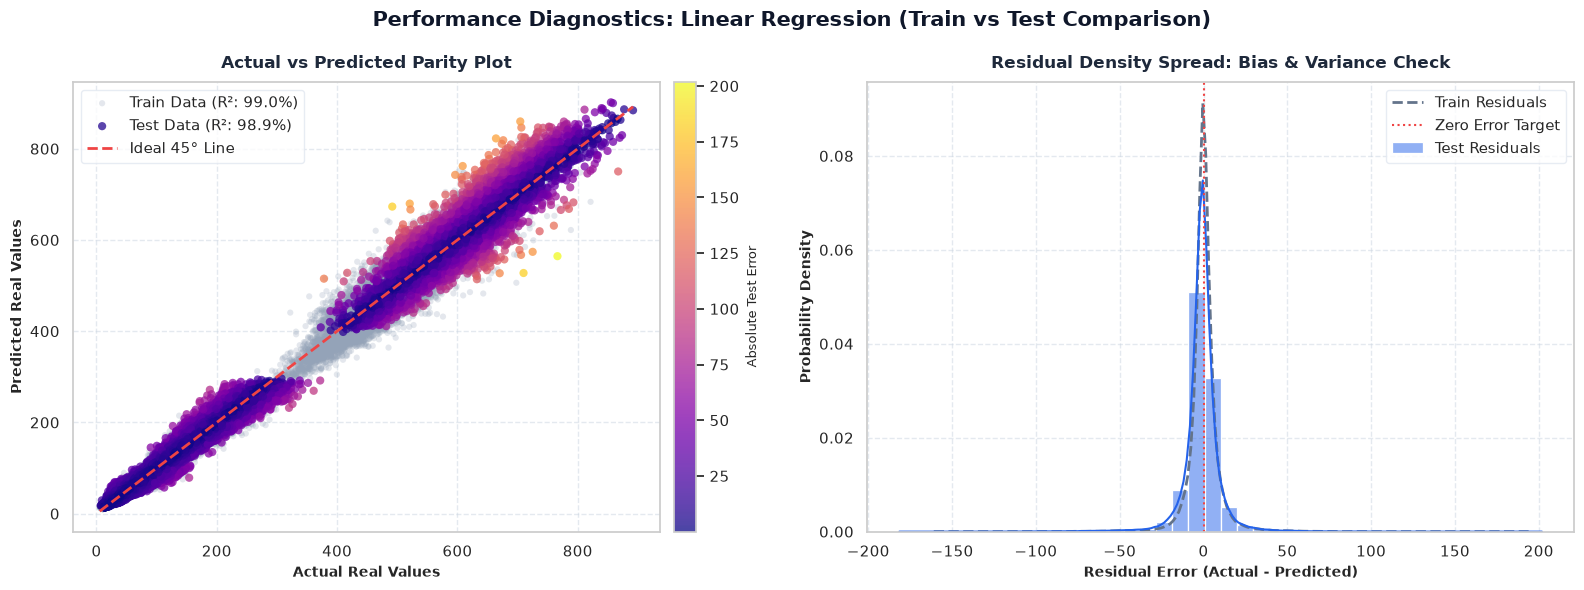

findfont: Failed to find font weight medium, now using 400.


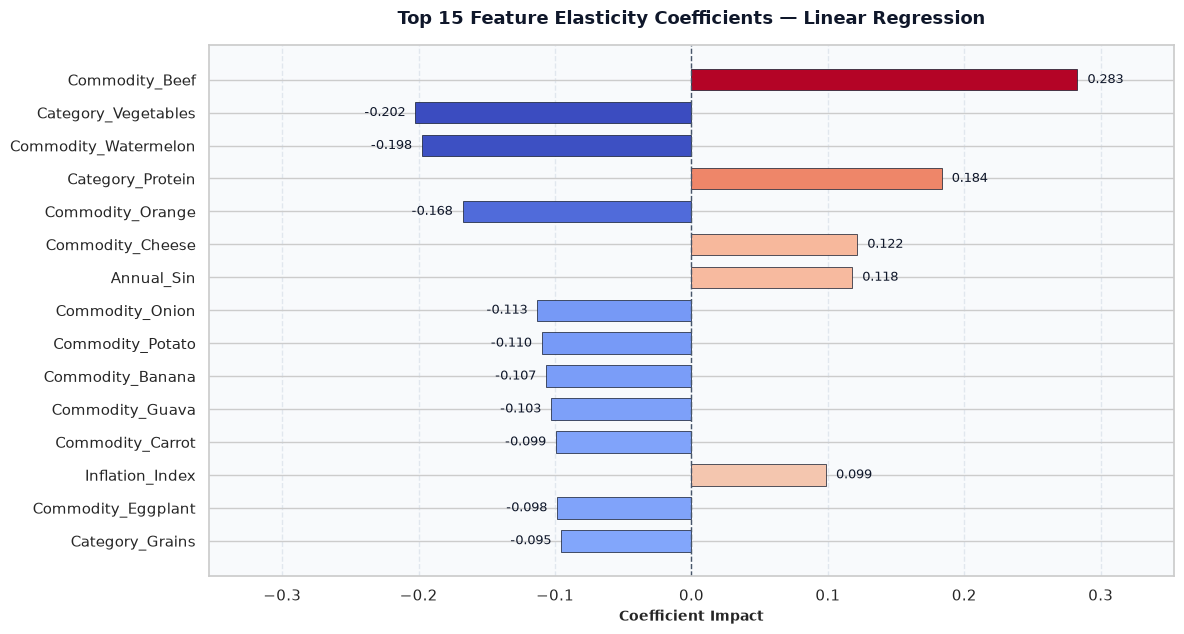

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,Linear Regression,98.99%,98.93%,+0.06%,5.47,6.67,9.55,11.66


In [62]:
evaluate_and_plot_model(
    model=lr,
    model_name="Linear Regression",
)

In [63]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 


========================= Decision Tree Regressor Generalization Diagnostics =========================
Train R²: 100.00% | Test R²: 97.81% | Overfitting Gap: +2.19%
Train MAE: 0.00 | Test MAE: 9.28
Train RMSE: 0.00 | Test RMSE: 16.71


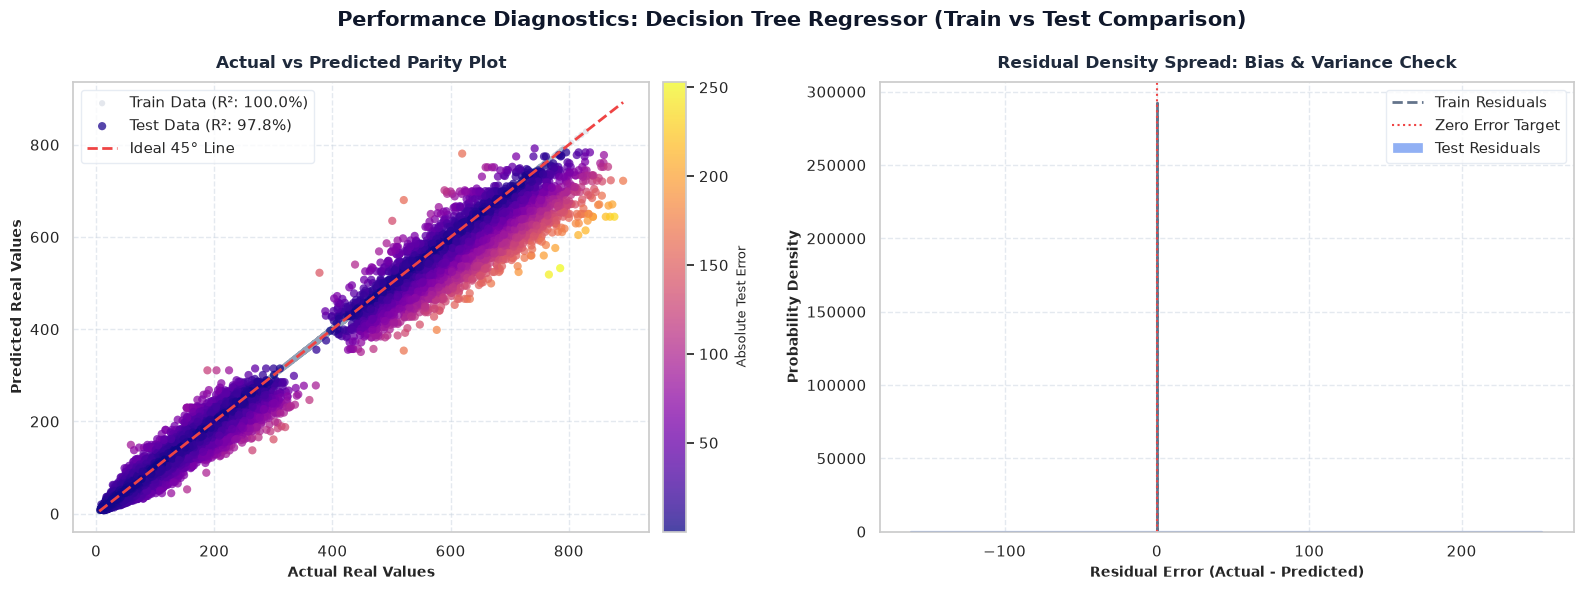

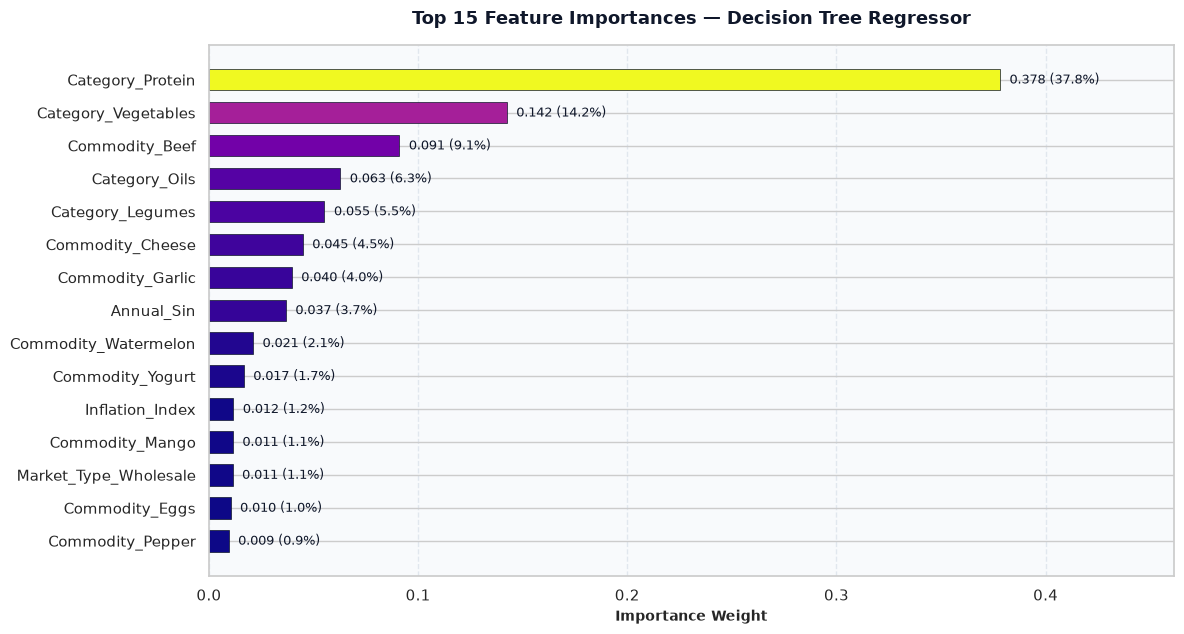

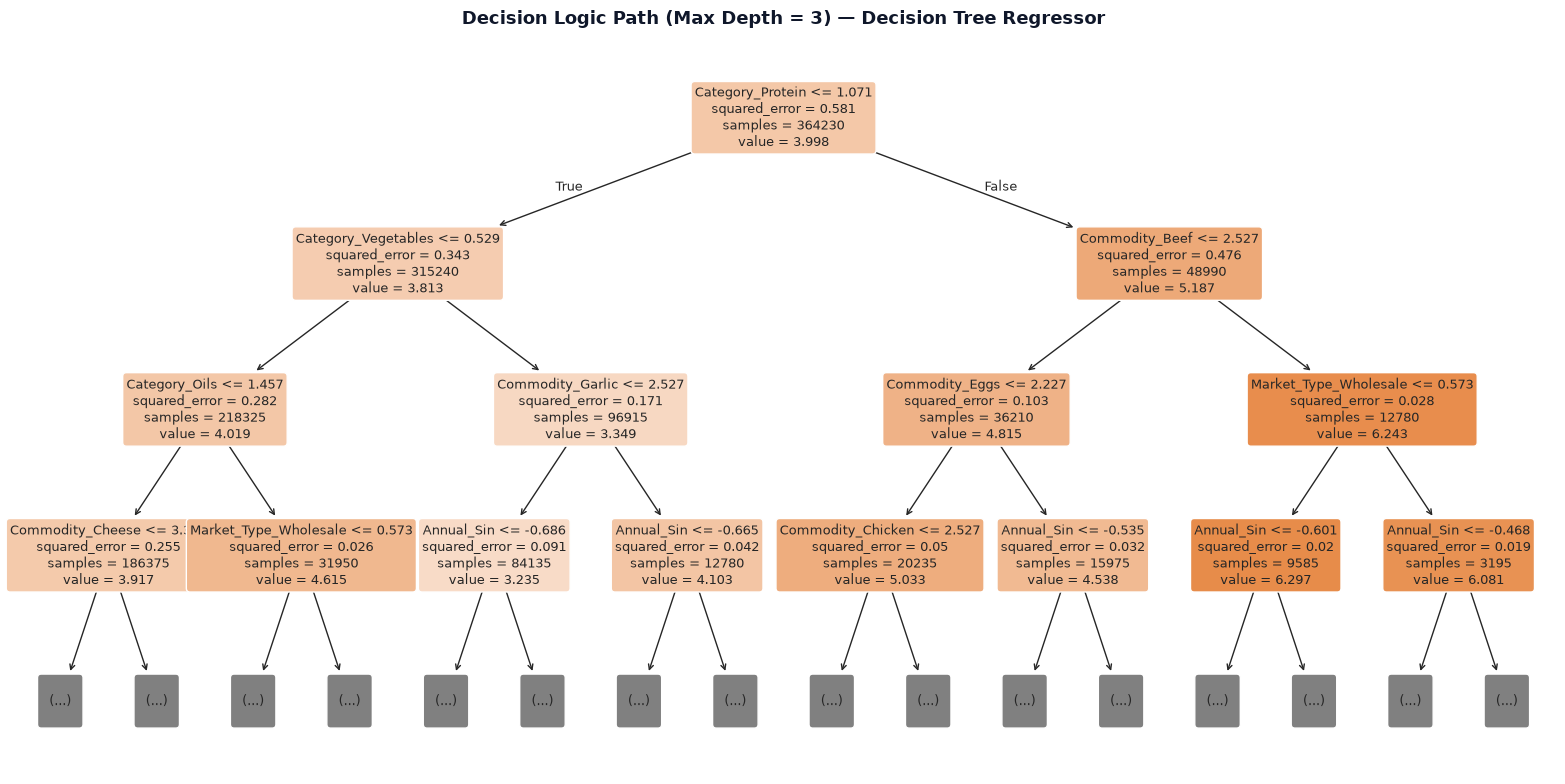

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,Decision Tree Regressor,100.00%,97.81%,+2.19%,0.00,9.28,0.00,16.71


In [64]:
evaluate_and_plot_model(
    model=tree,
    model_name="Decision Tree Regressor",
)

In [65]:
forest = RandomForestRegressor(n_jobs=-1,random_state= 42)
forest.fit(X_train,y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m


========================= Random Forest Regressor Generalization Diagnostics =========================
Train R²: 99.91% | Test R²: 98.40% | Overfitting Gap: +1.52%
Train MAE: 1.52 | Test MAE: 7.99
Train RMSE: 2.80 | Test RMSE: 14.29


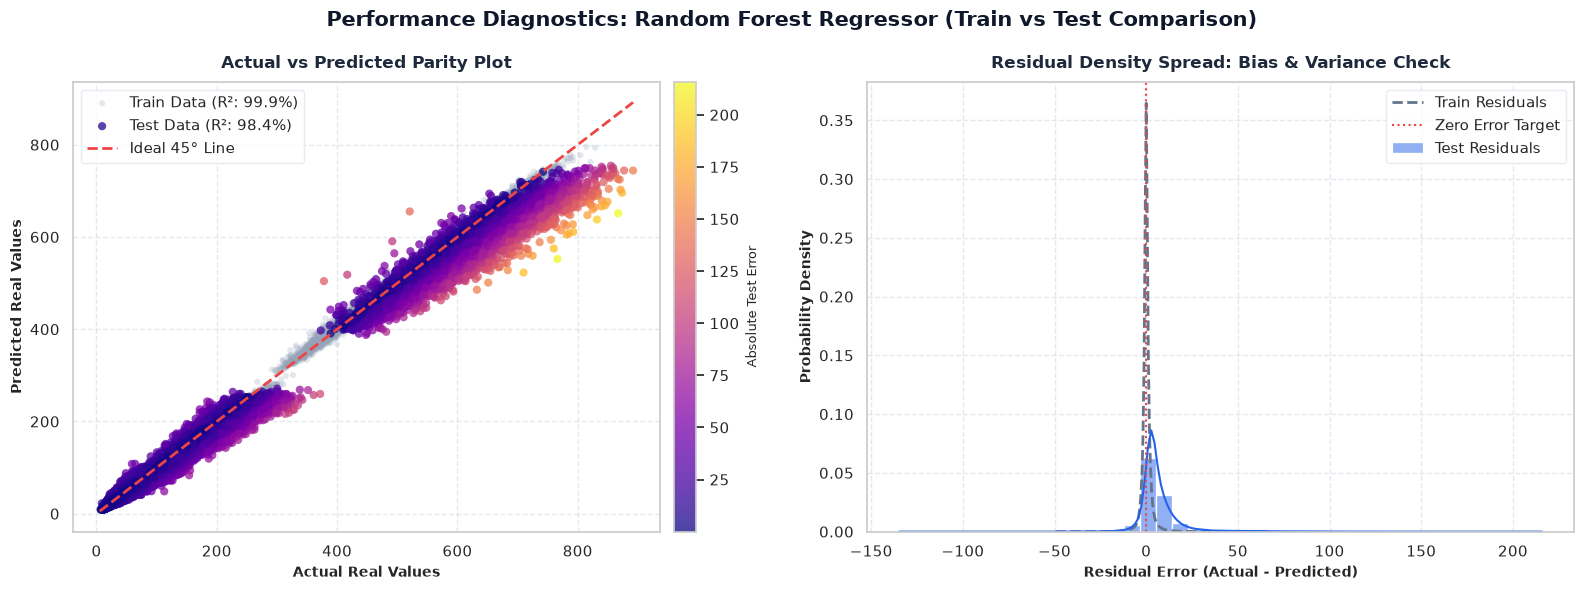

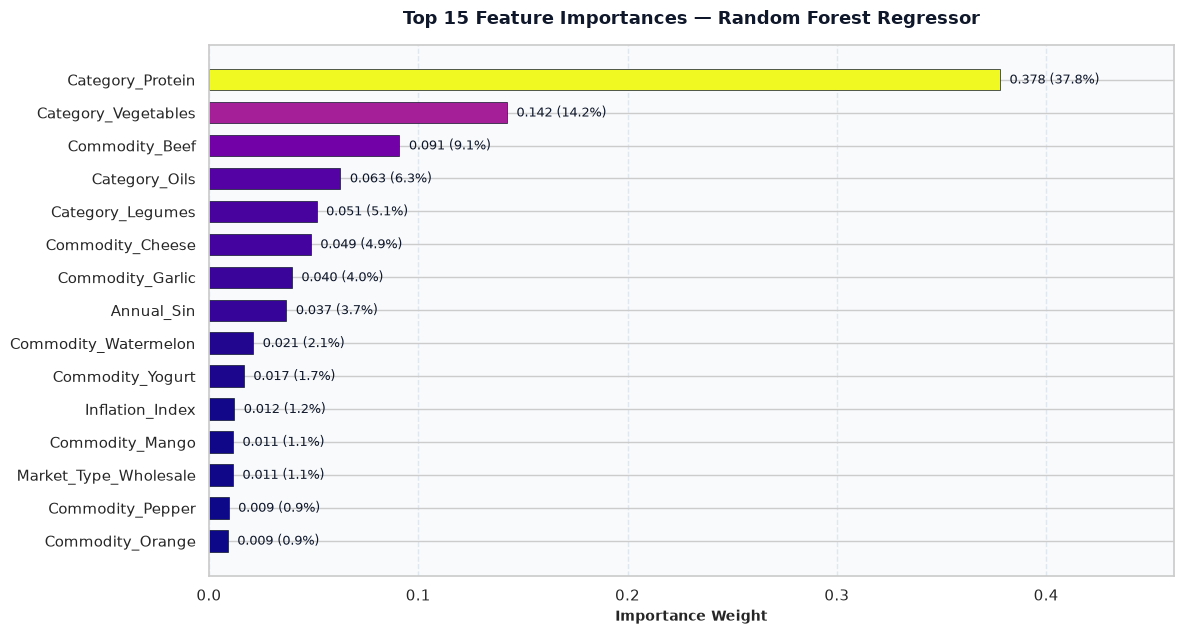

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,Random Forest Regressor,99.91%,98.40%,+1.52%,1.52,7.99,2.80,14.29


In [66]:
evaluate_and_plot_model(
    model=forest,
    model_name="Random Forest Regressor",
)

In [67]:
gradient = GradientBoostingRegressor(random_state= 42)
gradient.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf


========================= Gradient Boosting Regressor Generalization Diagnostics =========================
Train R²: 97.91% | Test R²: 94.50% | Overfitting Gap: +3.41%
Train MAE: 7.57 | Test MAE: 13.95
Train RMSE: 13.72 | Test RMSE: 26.46


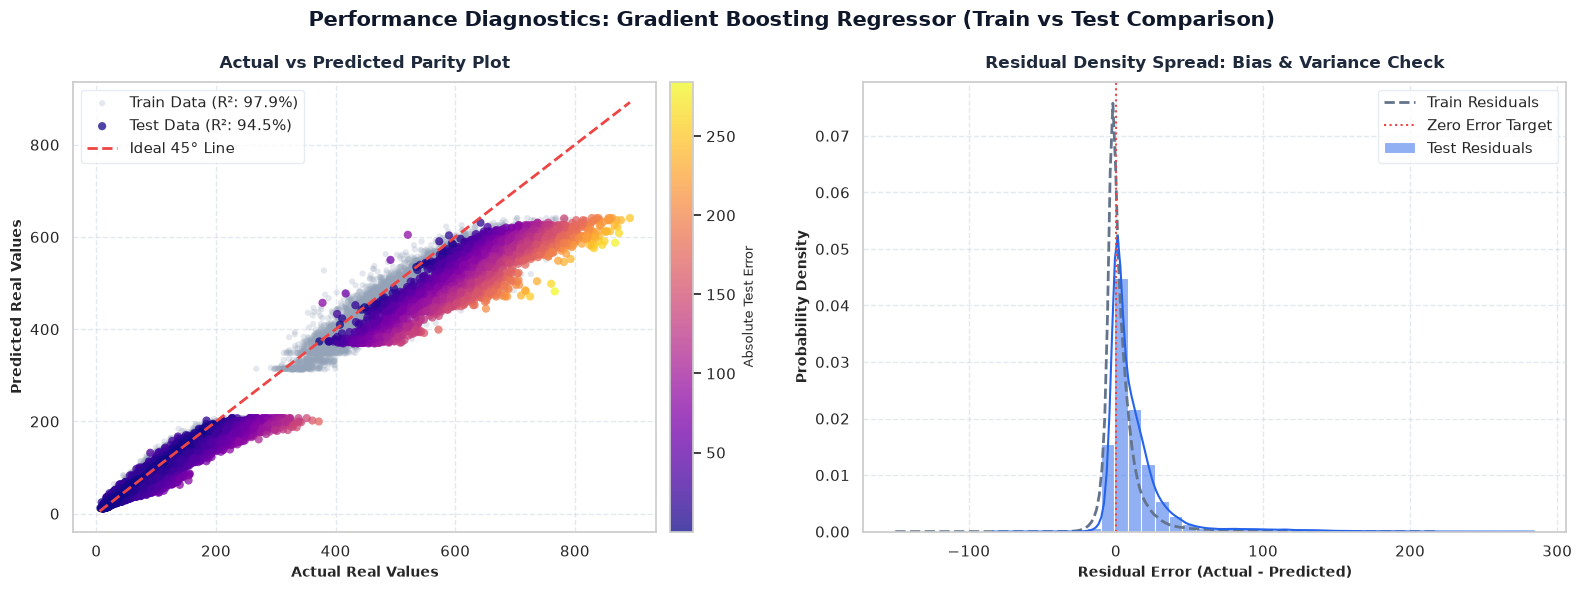

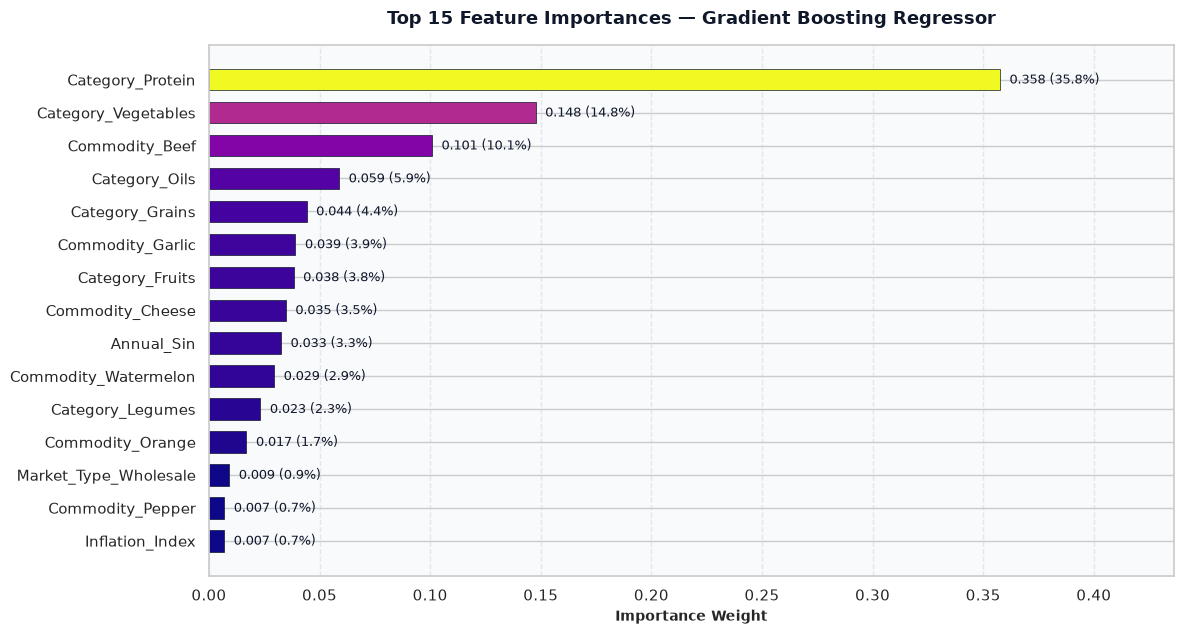

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,Gradient Boosting Regressor,97.91%,94.50%,+3.41%,7.57,13.95,13.72,26.46


In [68]:
evaluate_and_plot_model(
    model=gradient,
    model_name="Gradient Boosting Regressor",
)

In [69]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}



========================= K Neighbors Regressor Generalization Diagnostics =========================
Train R²: 99.55% | Test R²: 98.26% | Overfitting Gap: +1.29%
Train MAE: 3.53 | Test MAE: 8.38
Train RMSE: 6.40 | Test RMSE: 14.90


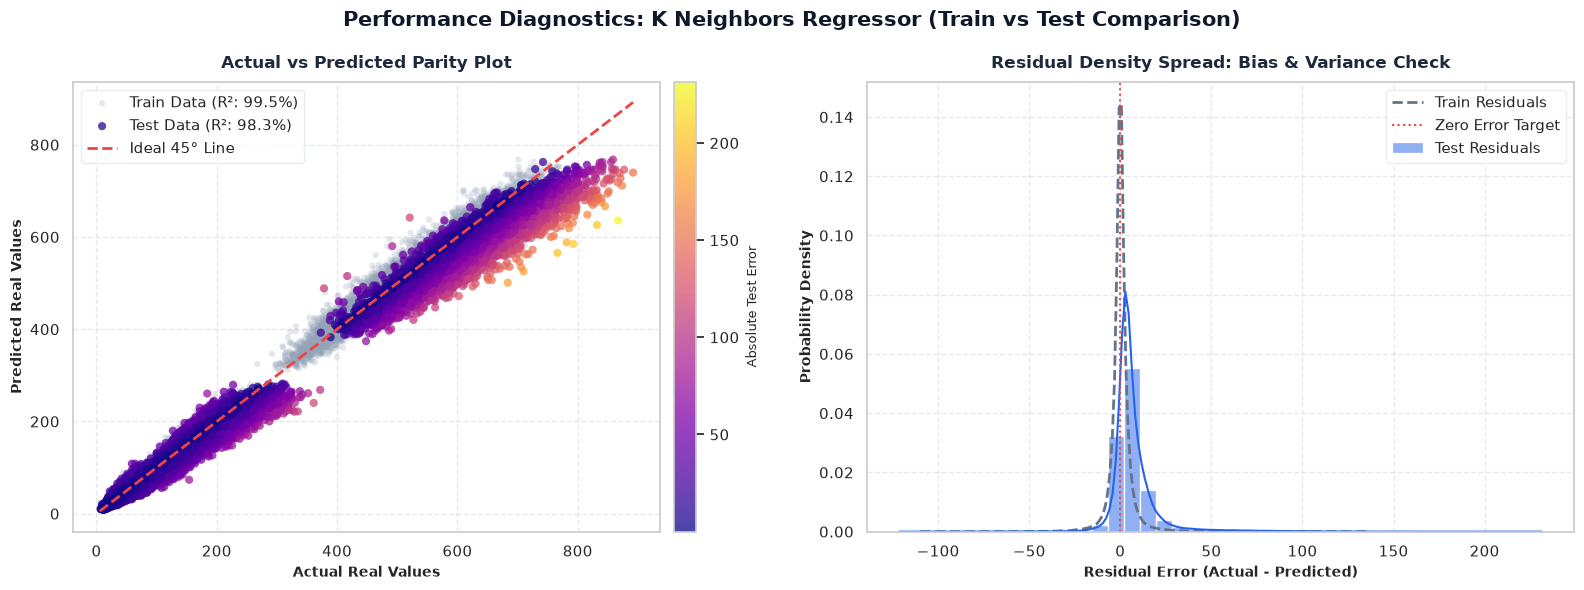

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,K Neighbors Regressor,99.55%,98.26%,+1.29%,3.53,8.38,6.40,14.90


In [70]:
evaluate_and_plot_model(
    model=knn,
    model_name="K Neighbors Regressor",
)

In [71]:
XGB =XGBRegressor(random_state= 42)
XGB.fit(X_train,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None



========================= XGB Regressor Generalization Diagnostics =========================
Train R²: 99.41% | Test R²: 98.58% | Overfitting Gap: +0.84%
Train MAE: 4.03 | Test MAE: 7.63
Train RMSE: 7.28 | Test RMSE: 13.47


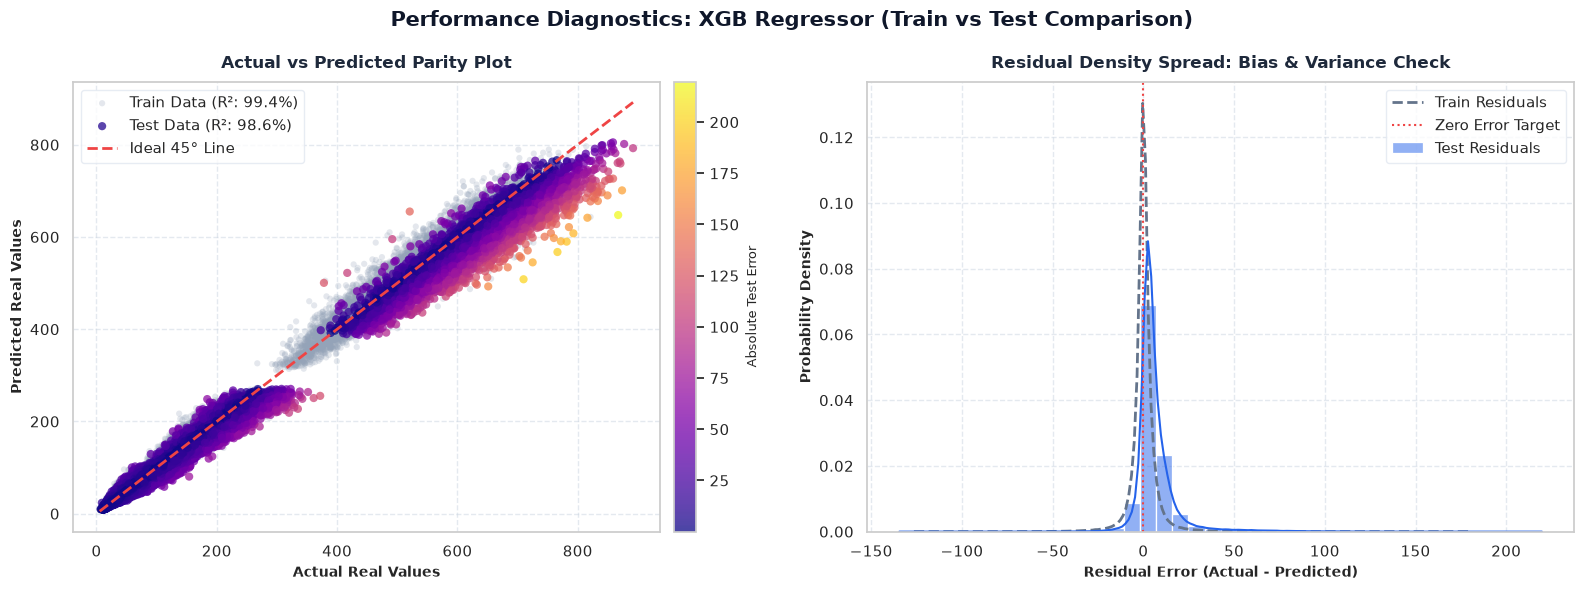

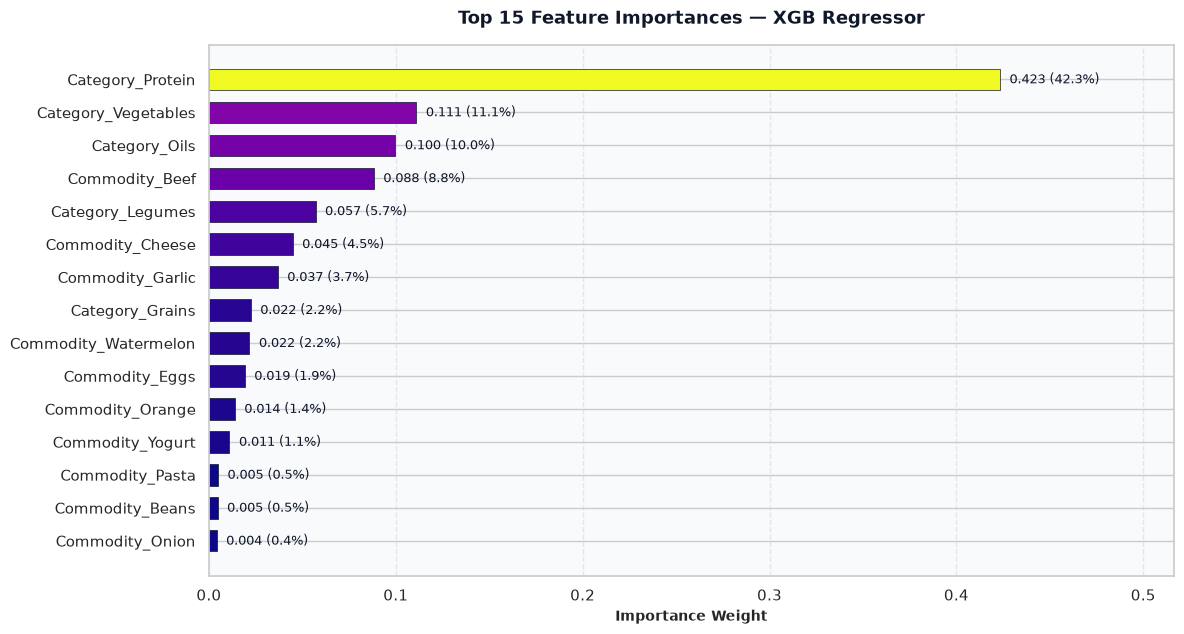

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,XGB Regressor,99.41%,98.58%,+0.84%,4.03,7.63,7.28,13.47


In [72]:
evaluate_and_plot_model(
    model=XGB,
    model_name="XGB Regressor",
)

In [73]:
lgbm =LGBMRegressor(n_jobs= -1, verbose=-1,random_state= 42)
lgbm.fit(X_train,y_train)

,random_state,42
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None



========================= LGBM Regressor Generalization Diagnostics =========================
Train R²: 99.35% | Test R²: 98.06% | Overfitting Gap: +1.29%
Train MAE: 4.22 | Test MAE: 8.42
Train RMSE: 7.65 | Test RMSE: 15.71


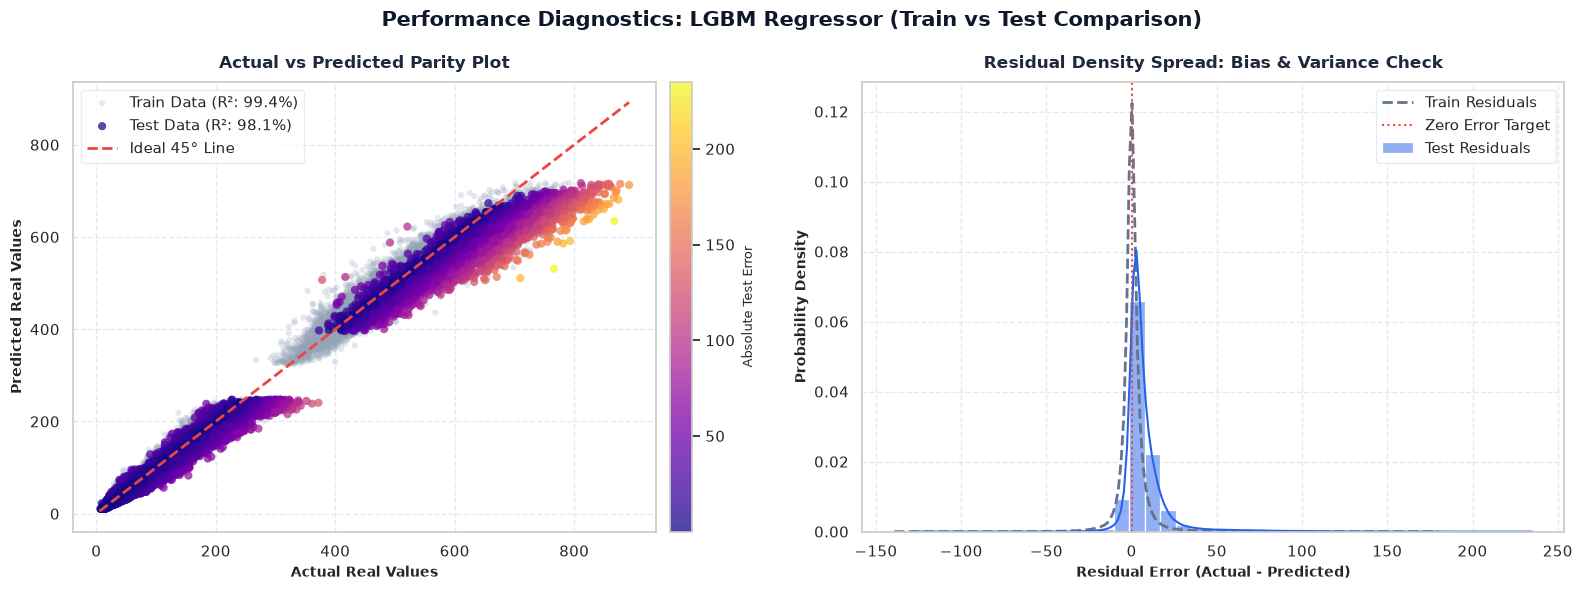

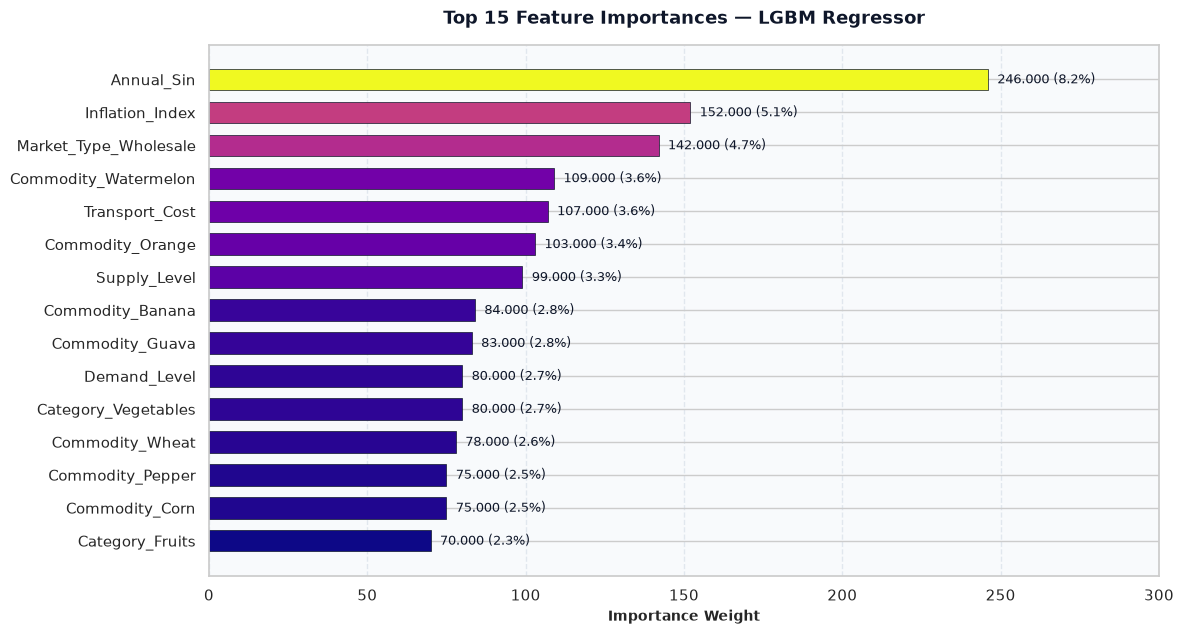

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,LGBM Regressor,99.35%,98.06%,+1.29%,4.22,8.42,7.65,15.71


In [74]:
evaluate_and_plot_model(
    model=lgbm,
    model_name="LGBM Regressor",
)

In [75]:
cat = CatBoostRegressor(verbose=0)
cat.fit(X_train,y_train)

CatBoostRegressor(loss_function='RMSE', verbose=0)


========================= CatBoost Regressor Generalization Diagnostics =========================
Train R²: 99.45% | Test R²: 98.69% | Overfitting Gap: +0.76%
Train MAE: 3.89 | Test MAE: 7.31
Train RMSE: 7.07 | Test RMSE: 12.93


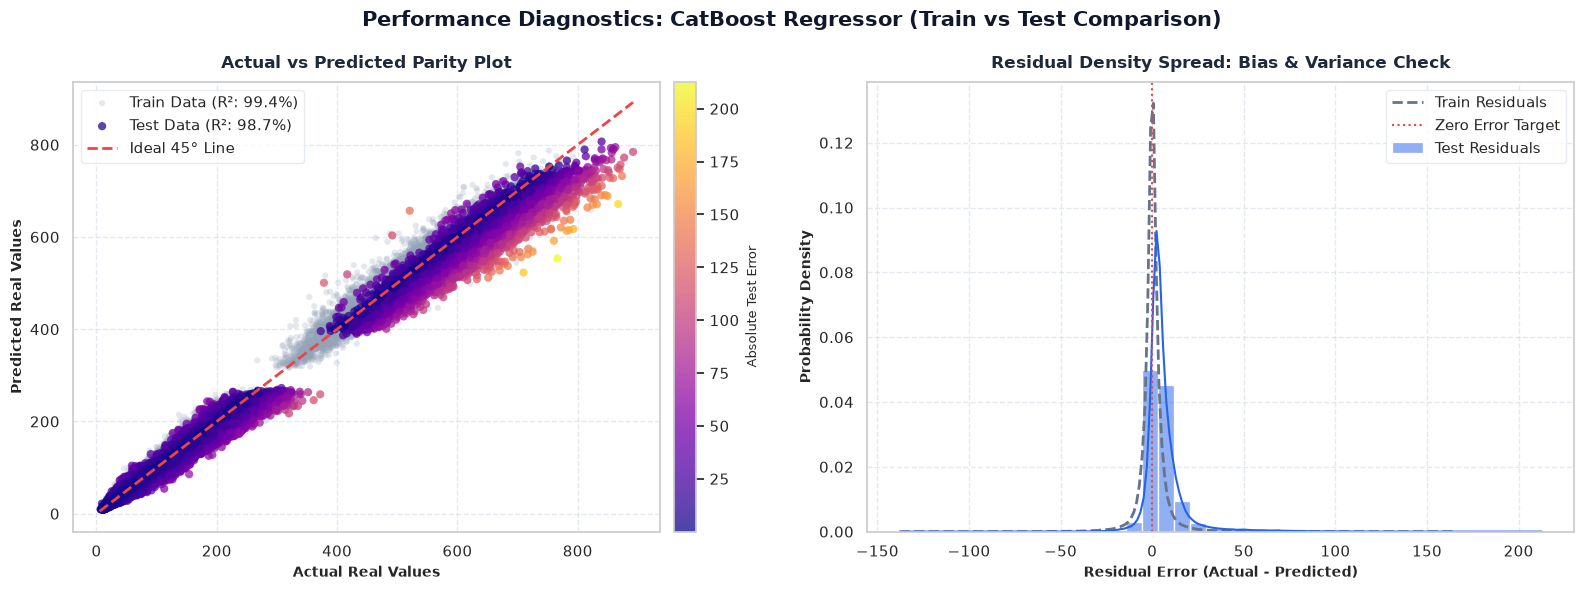

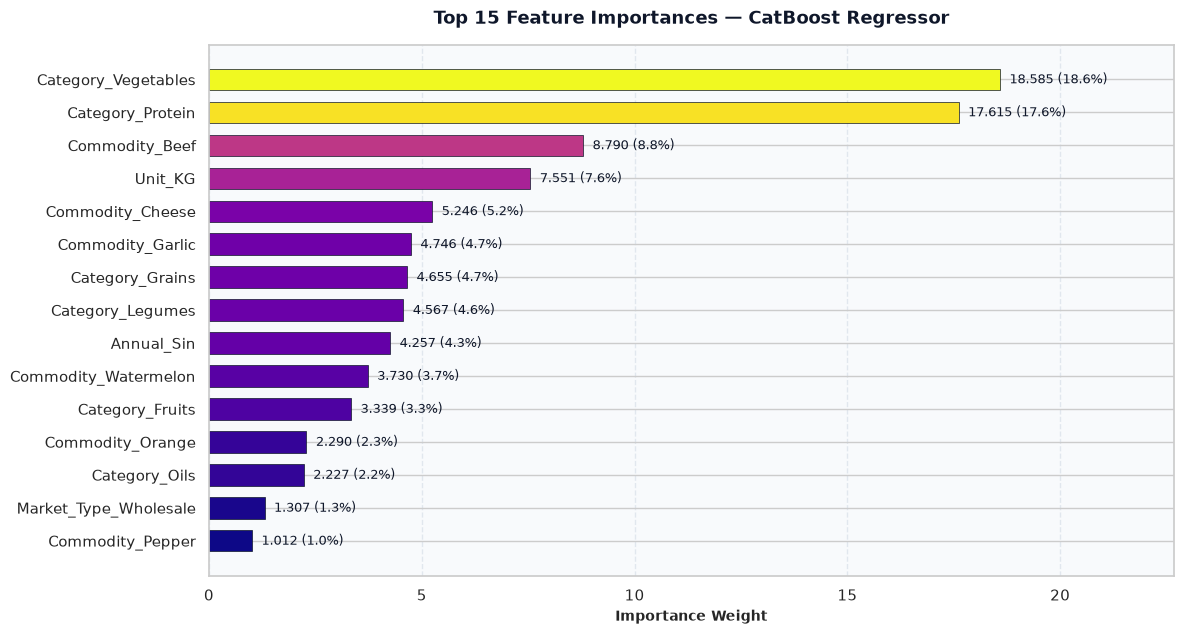

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,CatBoost Regressor,99.45%,98.69%,+0.76%,3.89,7.31,7.07,12.93


In [76]:
evaluate_and_plot_model(
    model=cat,
    model_name="CatBoost Regressor",
)

In [77]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=256,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=20,
    random_state=42,
    verbose=True
)
mlp.fit(X_train,y_train)

Iteration 1, loss = 0.04276572
Validation score: 0.983620
Iteration 2, loss = 0.00451417
Validation score: 0.985189
Iteration 3, loss = 0.00430367
Validation score: 0.983459
Iteration 4, loss = 0.00427422
Validation score: 0.985561
Iteration 5, loss = 0.00430868
Validation score: 0.984047
Iteration 6, loss = 0.00422987
Validation score: 0.985286
Iteration 7, loss = 0.00421088
Validation score: 0.985599
Iteration 8, loss = 0.00412182
Validation score: 0.984054
Iteration 9, loss = 0.00406303
Validation score: 0.985191
Iteration 10, loss = 0.00403630
Validation score: 0.985066
Iteration 11, loss = 0.00401697
Validation score: 0.985592
Iteration 12, loss = 0.00397414
Validation score: 0.985651
Iteration 13, loss = 0.00393379
Validation score: 0.987145
Iteration 14, loss = 0.00390235
Validation score: 0.986066
Iteration 15, loss = 0.00389979
Validation score: 0.987088
Iteration 16, loss = 0.00385751
Validation score: 0.986785
Iteration 17, loss = 0.00384296
Validation score: 0.987225
Iterat

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'adaptive'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by atleast ``tol`` for ``n_iter_no_change`` consecutive epochs.Only effective when solver='sgd' or 'adam'.",True
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.2
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",20
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'



========================= MLP Regressor Generalization Diagnostics =========================
Train R²: 99.40% | Test R²: 99.37% | Overfitting Gap: +0.03%
Train MAE: 4.01 | Test MAE: 5.03
Train RMSE: 7.36 | Test RMSE: 8.98


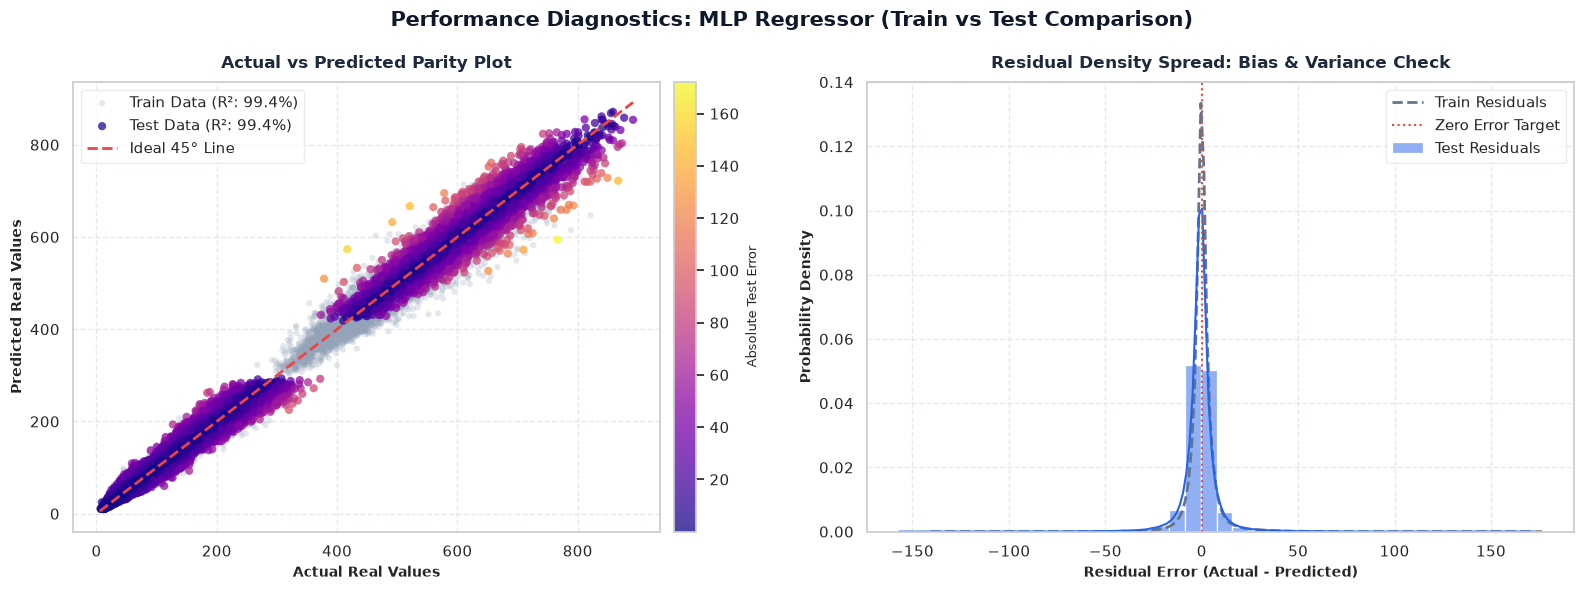

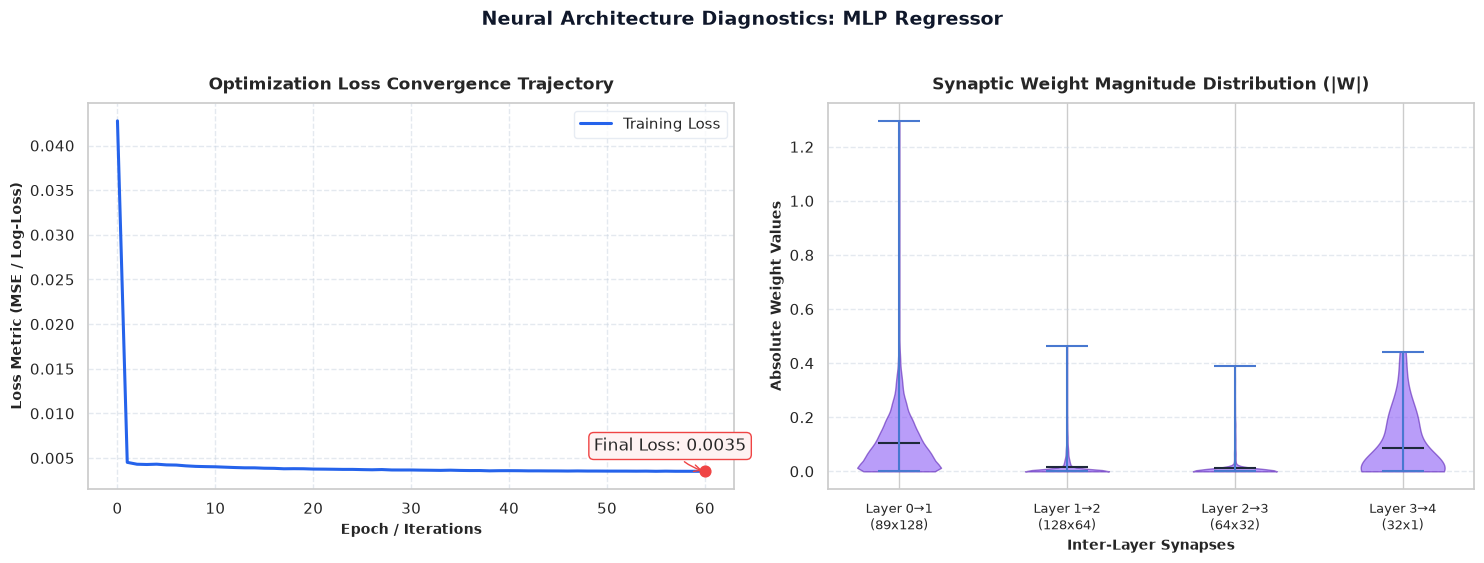

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,MLP Regressor,99.40%,99.37%,+0.03%,4.01,5.03,7.36,8.98


In [78]:
evaluate_and_plot_model(
    model=mlp,
    model_name="MLP Regressor",
)

In [79]:
vot =VotingRegressor([('cat', cat),('xgb',XGB),('linear',lr)])
vot.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('xgb', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[CatBoostRegre...E', verbose=0), XGBRegressor(...ree=None, ...), LinearRegression()]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,89
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'cat': CatBo...rRegression()}
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None



========================= Voting Regressor Generalization Diagnostics =========================
Train R²: 99.40% | Test R²: 99.09% | Overfitting Gap: +0.31%
Train MAE: 4.11 | Test MAE: 6.00
Train RMSE: 7.38 | Test RMSE: 10.77


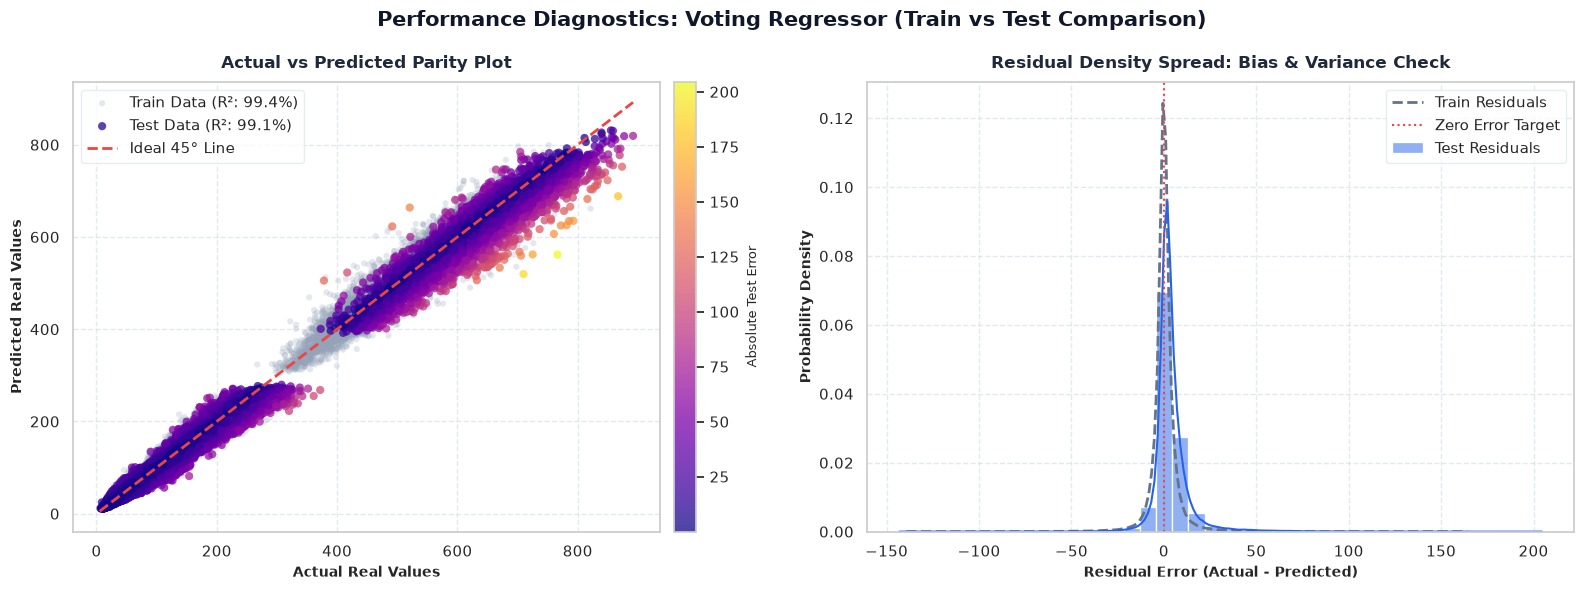

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,Voting Regressor,99.40%,99.09%,+0.31%,4.11,6.00,7.38,10.77


In [80]:
evaluate_and_plot_model(
    model=vot,
    model_name="Voting Regressor",
)

In [81]:
stack =StackingRegressor(estimators=[('cat', cat),('xgb',XGB),('linear',lr)],
                         final_estimator=lr,
                         cv=5)
stack.fit(X_train,y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('cat', ...), ('xgb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",LinearRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[CatBoostRegre...E', verbose=0), XGBRegressor(...ree=None, ...), LinearRegression()]"
final_estimator_ final_estimator_: estimatorThe regressor fit on the output of `estimators_` and responsible forfinal predictions.,LinearRegression,LinearRegression()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,89
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name.,Bunch,{'cat': CatBo...rRegression()}



========================= Stacking Regressor Generalization Diagnostics =========================
Train R²: 99.44% | Test R²: 98.80% | Overfitting Gap: +0.64%
Train MAE: 3.90 | Test MAE: 7.07
Train RMSE: 7.08 | Test RMSE: 12.37


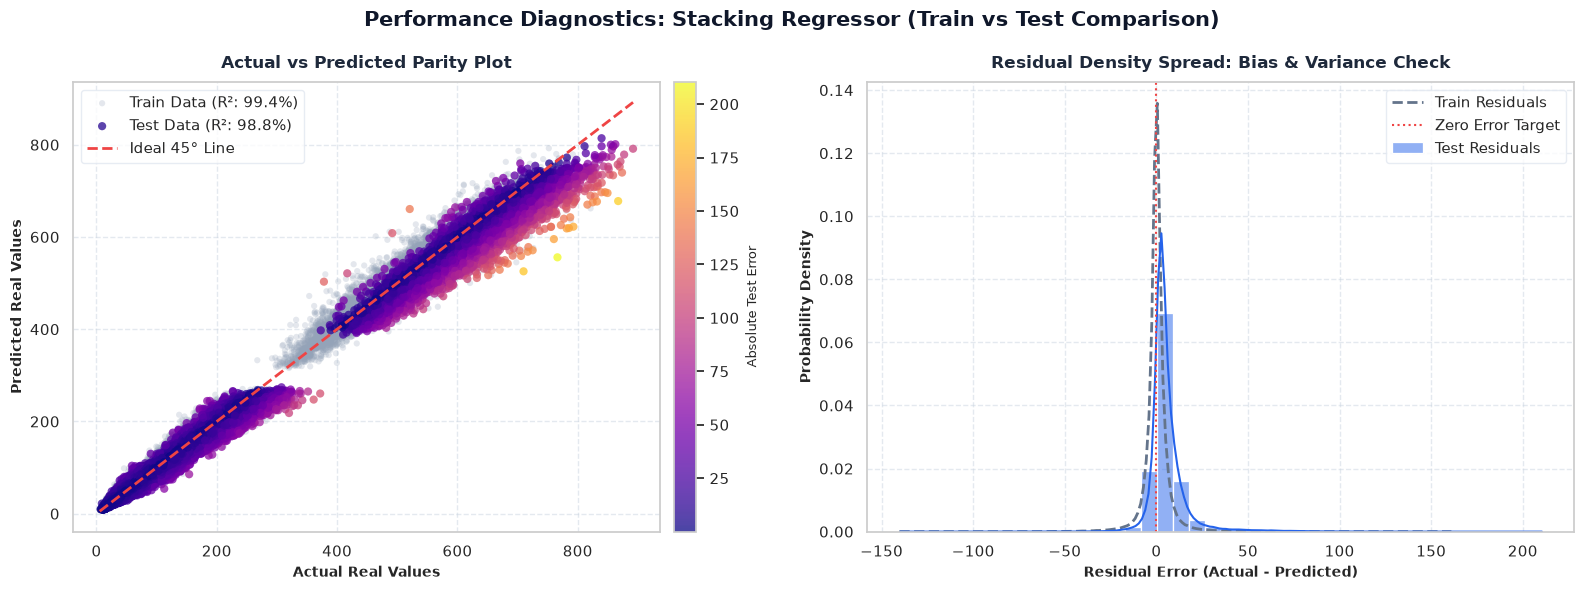

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,Stacking Regressor,99.44%,98.80%,+0.64%,3.90,7.07,7.08,12.37


In [82]:
evaluate_and_plot_model(
    model=stack,
    model_name="Stacking Regressor",
)

In [83]:
get_model_comparison_summary()

,Model Name,R2 Train (%),R2 Test (%),R2 Gap (%),MAE Train,MAE Test,RMSE Train,RMSE Test
0,MLP Regressor,99.40%,99.37%,+0.03%,4.01,5.03,7.36,8.98
1,Voting Regressor,99.40%,99.09%,+0.31%,4.11,6.00,7.38,10.77
2,Linear Regression,98.99%,98.93%,+0.06%,5.47,6.67,9.55,11.66
3,Stacking Regressor,99.44%,98.80%,+0.64%,3.90,7.07,7.08,12.37
4,CatBoost Regressor,99.45%,98.69%,+0.76%,3.89,7.31,7.07,12.93
5,XGB Regressor,99.41%,98.58%,+0.84%,4.03,7.63,7.28,13.47
6,Random Forest Regressor,99.91%,98.40%,+1.52%,1.52,7.99,2.80,14.29
7,K Neighbors Regressor,99.55%,98.26%,+1.29%,3.53,8.38,6.40,14.90
8,LGBM Regressor,99.35%,98.06%,+1.29%,4.22,8.42,7.65,15.71
9,Decision Tree Regressor,100.00%,97.81%,+2.19%,0.00,9.28,0.00,16.71


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


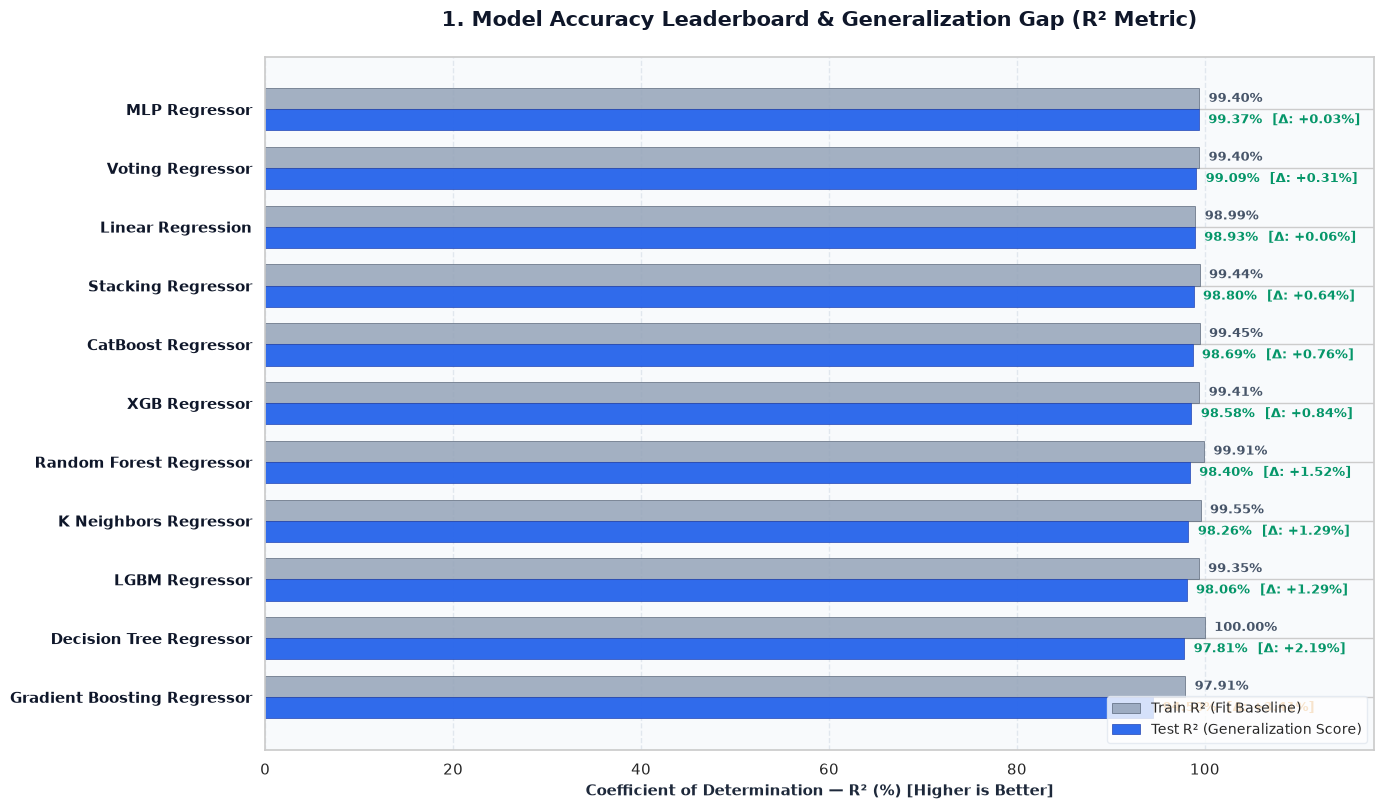

findfont: Failed to find font weight semibold, now using 700.


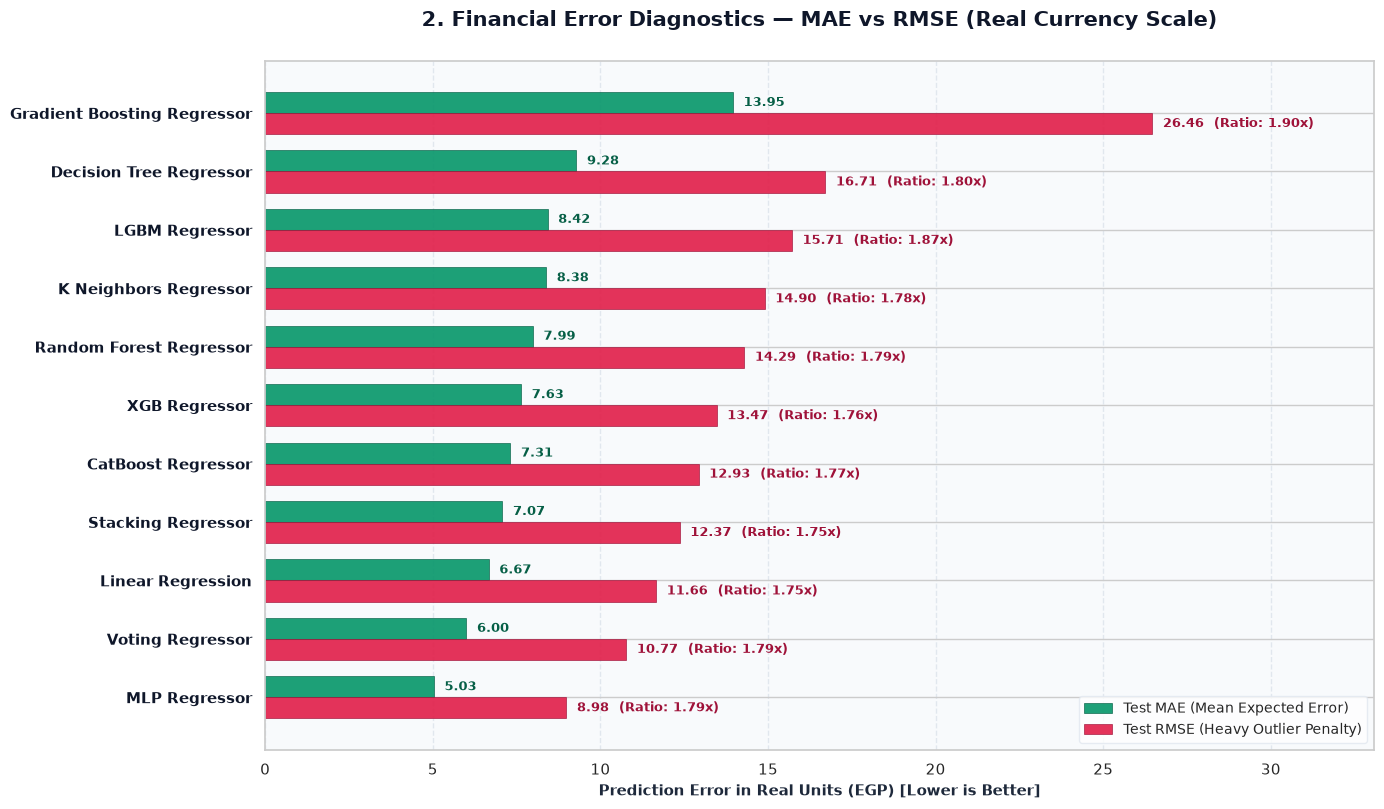

In [84]:

r2_test_col = 'R2 Test (%)' if 'R2 Test (%)' in model_comparison_df.columns else 'R2 Score'
r2_train_col = 'R2 Train (%)' if 'R2 Train (%)' in model_comparison_df.columns else r2_test_col
r2_gap_col = 'R2 Gap (%)' if 'R2 Gap (%)' in model_comparison_df.columns else None

mae_test_col = 'MAE Test' if 'MAE Test' in model_comparison_df.columns else 'MAE'
rmse_test_col = 'RMSE Test' if 'RMSE Test' in model_comparison_df.columns else 'RMSE'

df_valid = model_comparison_df[model_comparison_df[r2_test_col] > 35].copy()
df_r2_sorted = df_valid.sort_values(by=r2_test_col, ascending=True).reset_index(drop=True)


fig1, ax1 = plt.subplots(figsize=(14, max(6, len(df_r2_sorted) * 0.75)), facecolor='#FFFFFF')
ax1.set_facecolor('#F8FAFC')

y_indices = np.arange(len(df_r2_sorted))
bar_height = 0.36

bars_train = ax1.barh(
    y_indices + bar_height / 2, 
    df_r2_sorted[r2_train_col], 
    height=bar_height, 
    color='#94A3B8', 
    label='Train R² (Fit Baseline)', 
    edgecolor='#475569',
    linewidth=0.5,
    alpha=0.85
)

bars_test = ax1.barh(
    y_indices - bar_height / 2, 
    df_r2_sorted[r2_test_col], 
    height=bar_height, 
    color='#2563EB', 
    label='Test R² (Generalization Score)', 
    edgecolor='#1E40AF',
    linewidth=0.5,
    alpha=0.95
)

for i, (idx, row) in enumerate(df_r2_sorted.iterrows()):
    train_v = row[r2_train_col]
    test_v = row[r2_test_col]
    gap = row[r2_gap_col] if r2_gap_col else (train_v - test_v)
    
    ax1.text(
        train_v + 1.0, 
        y_indices[i] + bar_height / 2, 
        f'{train_v:.2f}%', 
        va='center', ha='left', fontsize=9, color='#475569', fontweight='semibold'
    )
    
    gap_color = '#059669' if gap <= 3.0 else ('#D97706' if gap <= 8.0 else '#DC2626')
    gap_badge = f'Δ: {gap:+.2f}%'
    
    ax1.text(
        test_v + 1.0, 
        y_indices[i] - bar_height / 2, 
        f'{test_v:.2f}%  [{gap_badge}]', 
        va='center', ha='left', fontsize=9.5, color=gap_color, fontweight='bold'
    )

ax1.set_yticks(y_indices)
ax1.set_yticklabels(df_r2_sorted['Model Name'], fontsize=11, fontweight='semibold', color='#0F172A')
ax1.set_title('1. Model Accuracy Leaderboard & Generalization Gap (R² Metric)', fontsize=15, fontweight='bold', pad=22, color='#0F172A')
ax1.set_xlabel('Coefficient of Determination — R² (%) [Higher is Better]', fontsize=11, fontweight='bold', color='#1E293B')
ax1.set_xlim(0, 118)
ax1.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1', axis='x')

ax1.legend(loc='lower right', frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0', fontsize=10)

plt.tight_layout()
plt.show()


df_err_sorted = df_valid.sort_values(by=rmse_test_col, ascending=True).reset_index(drop=True)

fig2, ax2 = plt.subplots(figsize=(14, max(6, len(df_err_sorted) * 0.75)), facecolor='#FFFFFF')
ax2.set_facecolor('#F8FAFC')

y_indices = np.arange(len(df_err_sorted))

bars_mae = ax2.barh(
    y_indices + bar_height / 2, 
    df_err_sorted[mae_test_col], 
    height=bar_height, 
    color='#059669', 
    label='Test MAE (Mean Expected Error)', 
    edgecolor='#065F46',
    linewidth=0.5,
    alpha=0.9
)

bars_rmse = ax2.barh(
    y_indices - bar_height / 2, 
    df_err_sorted[rmse_test_col], 
    height=bar_height, 
    color='#E11D48', 
    label='Test RMSE (Heavy Outlier Penalty)', 
    edgecolor='#9F1239',
    linewidth=0.5,
    alpha=0.9
)

max_err = df_err_sorted[rmse_test_col].max()
for i, (idx, row) in enumerate(df_err_sorted.iterrows()):
    mae_v = row[mae_test_col]
    rmse_v = row[rmse_test_col]
    ratio = (rmse_v / mae_v) if mae_v > 0 else 1.0
   
    ax2.text(
        mae_v + (max_err * 0.012), 
        y_indices[i] + bar_height / 2, 
        f'{mae_v:,.2f}', 
        va='center', ha='left', fontsize=9.5, color='#065F46', fontweight='semibold'
    )
    
    ax2.text(
        rmse_v + (max_err * 0.012), 
        y_indices[i] - bar_height / 2, 
        f'{rmse_v:,.2f}  (Ratio: {ratio:.2f}x)', 
        va='center', ha='left', fontsize=9.5, color='#9F1239', fontweight='bold'
    )

ax2.set_yticks(y_indices)
ax2.set_yticklabels(df_err_sorted['Model Name'], fontsize=11, fontweight='semibold', color='#0F172A')
ax2.set_title('2. Financial Error Diagnostics — MAE vs RMSE (Real Currency Scale)', fontsize=15, fontweight='bold', pad=25, color='#0F172A')
ax2.set_xlabel('Prediction Error in Real Units (EGP) [Lower is Better]', fontsize=11, fontweight='bold', color='#1E293B')

ax2.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax2.set_xlim(0, max_err * 1.25)
ax2.grid(True, linestyle='--', alpha=0.5, color='#CBD5E1', axis='x')

ax2.legend(loc='lower right', frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0', fontsize=10)

plt.tight_layout()
plt.show()

In [86]:
import joblib

production_artifacts = {
    'model': lr,
    'scaler': scaler,
    'feature_names': feature_names,
    'original_features': FEATURES,
    'categorical_features': ['Governorate', 'Region', 'Market_Type', 'Commodity', 'Category', 'Unit', 'Season']
}

model_filename = 'egypt_food_price_LinearRegression_model.pkl'
joblib.dump(production_artifacts, model_filename)

print(f"✅ {model_filename}")

✅ egypt_food_price_LinearRegression_model.pkl
